In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

from setting_for_sdm.path_setting import path_list
from setting_for_sdm.date_setting import Date_Setting
from setting_for_sdm.constants import CONSTANTS

from lib.code_complexity.cyclomatic_complexity import calculate_cyclomatic_complexity
from lib.utils.file_io import read_complexity_jsonl

import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.figure_setting as figure_setting
mpl.rcParams.update(figure_setting.fig_setting)
import matplotlib.pyplot as plt
# plt.rcParams['font.family'] = 'DejaVu Sans'   # 그리스 지원

import statsmodels.formula.api as smf
from scipy import stats





In [2]:
run_id_start = 20000

tot_viz_df = pd.DataFrame()
for idx, lang in enumerate(list({lang: set_ for lang, set_ in CONSTANTS.LANG_INFO.items() if set_[1] is not None}.keys())):
    print(f'[visualizing....] start visualizing {lang} language')
    output_dir = create_dir('./fig/')
    src_dir = f'{path_list["data_root_dir"]}/result/code_complexity/cyclomatic_complexity/run_id_{run_id_start+idx}'
    option_dict = load_json(f"{src_dir}/data/option.json")
    std_date = Date_Setting[option_dict['year_range']]['std_date']

    origin_df = load_df(option_dict['data_dir'], ['id', 'creationdate', 'title','tags', 'body'])
    df = read_complexity_jsonl(option_dict)
    viz_df = pd.merge(df, origin_df, on = 'id')[['id', 'creationdate', 'cyclomatic_complexity', 'nloc']]
    viz_df['language'] = lang
    tot_viz_df = pd.concat([tot_viz_df, viz_df], ignore_index=True)




[visualizing....] start visualizing python language


100%|██████████| 65/65 [00:13<00:00,  4.76it/s]


[visualizing....] start visualizing javascript language


100%|██████████| 65/65 [00:12<00:00,  5.11it/s]


[visualizing....] start visualizing java language


...

100%|██████████| 65/65 [00:00<00:00, 424.58it/s]


[visualizing....] start visualizing fortran language


100%|██████████| 65/65 [00:00<00:00, 608.53it/s]


[visualizing....] start visualizing solidity language


100%|██████████| 65/65 [00:00<00:00, 375.17it/s]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import linregress, ttest_1samp
from statsmodels.stats.multitest import multipletests

# ═══════════════════════════════════════════
# 0. 설정
# ═══════════════════════════════════════════
CHATGPT_DATE = pd.Timestamp('2022-11-30')
TARGET       = 'log_cc_mean'         # ⭐ 변수명 정직하게
BIN_SIZE     = 4
MIN_BIN      = -28
MAX_BIN      = +39
REF_BIN      = -1

MIN_LANGS_PER_BIN = 10
MIN_FUNC_PER_CELL = 50

# ═══════════════════════════════════════════
# 1. 데이터 준비
# ═══════════════════════════════════════════
df = tot_viz_df.copy()
df['creationdate'] = pd.to_datetime(df['creationdate'], format='mixed')
df = df[df['cyclomatic_complexity'] > 0].dropna(subset=['nloc']).copy()

# ⭐ 함수 단위에서 log 변환 (raw cc는 이상치 영향 큼)
df['log_cc'] = np.log1p(df['cyclomatic_complexity'])

df['week'] = df['creationdate'].dt.to_period('W').dt.start_time

valid = df['language'].value_counts()[lambda s: s >= 1000].index
df = df[df['language'].isin(valid)].copy()

# 주별 × 언어별 집계
weekly_var = df.groupby(['language', 'week']).agg(
    log_cc_mean = ('log_cc', 'mean'),                       # ⭐ log → mean
    log_cc_std  = ('log_cc', 'std'),
    cc_mean_raw = ('cyclomatic_complexity', 'mean'),        # 비교용 (raw)
    cc_std_raw  = ('cyclomatic_complexity', 'std'),
    n_func      = ('cyclomatic_complexity', 'count'),
).reset_index()

weekly_var = weekly_var[weekly_var['n_func'] >= 30].copy()
weekly_var['weeks_since'] = (weekly_var['week'] - CHATGPT_DATE).dt.days / 7

# Event time 빈
weekly_var['event_bin'] = (weekly_var['weeks_since'] // BIN_SIZE).astype(int)
weekly_var = weekly_var[
    (weekly_var['event_bin'] >= MIN_BIN) &
    (weekly_var['event_bin'] <= MAX_BIN)
].copy()

print(f"초기 데이터: {len(weekly_var):,}개 행, {weekly_var['language'].nunique()}개 언어")

# ⭐ log_cc_mean과 raw cc_mean 분포 비교 (확인용)
print(f"\n=== 종속변수 분포 비교 ===")
print(f"log_cc_mean: mean={weekly_var['log_cc_mean'].mean():.3f}, "
      f"std={weekly_var['log_cc_mean'].std():.3f}, "
      f"range=[{weekly_var['log_cc_mean'].min():.3f}, {weekly_var['log_cc_mean'].max():.3f}]")
print(f"cc_mean_raw: mean={weekly_var['cc_mean_raw'].mean():.3f}, "
      f"std={weekly_var['cc_mean_raw'].std():.3f}, "
      f"range=[{weekly_var['cc_mean_raw'].min():.3f}, {weekly_var['cc_mean_raw'].max():.3f}]")

# ═══════════════════════════════════════════
# 2. 진단
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("1단계: 데이터 진단")
print("="*60)

clean_data = weekly_var.dropna(subset=[TARGET])

bin_stats = clean_data.groupby('event_bin').agg(
    n_obs=(TARGET, 'count'),
    n_lang=('language', 'nunique'),
    total_func=('n_func', 'sum'),
).reset_index()
print(f"\n빈별 표본 분포:")
print(bin_stats.describe()[['n_obs', 'n_lang', 'total_func']].round(1))

pivot = clean_data.pivot_table(
    index='event_bin', columns='language',
    values=TARGET, aggfunc='count', fill_value=0,
)
n_empty = (pivot == 0).sum().sum()
n_total = pivot.size
print(f"\n빈×언어 매트릭스: {n_empty}/{n_total} 셀 비어 있음 ({n_empty/n_total*100:.1f}%)")

# ═══════════════════════════════════════════
# 3. 데이터 정제 (현재 비활성)
# ═══════════════════════════════════════════
weekly_clean = weekly_var.copy()

# ═══════════════════════════════════════════
# 4. 통합 Event Study 회귀
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("3단계: 통합 Event Study 회귀")
print("="*60)

formula_pool = (f'{TARGET} ~ C(event_bin, Treatment(reference={REF_BIN}))'
                f' + C(language)')

m_pool = smf.wls(formula_pool, data=weekly_clean,
                 weights=weekly_clean['n_func']).fit(
    cov_type='cluster', cov_kwds={'groups': weekly_clean['language']},
)
print(formula_pool)

pool_results = []
for term in m_pool.params.index:
    if 'C(event_bin' not in term:
        continue
    bin_val = int(term.split('T.')[1].split(']')[0])
    pool_results.append({
        'event_bin': bin_val,
        'weeks':     bin_val * BIN_SIZE,
        'coef':      m_pool.params[term],
        'se':        m_pool.bse[term],
        'p_value':   m_pool.pvalues[term],
        'ci_low':    m_pool.params[term] - 1.96 * m_pool.bse[term],
        'ci_high':   m_pool.params[term] + 1.96 * m_pool.bse[term],
    })
pool_results.append({
    'event_bin': REF_BIN, 'weeks': REF_BIN * BIN_SIZE,
    'coef': 0, 'se': 0, 'p_value': 1, 'ci_low': 0, 'ci_high': 0,
})
pool_df = pd.DataFrame(pool_results).sort_values('event_bin').reset_index(drop=True)

# ⭐ % 단위 변환 추가 (log 회귀 → % 해석)
def beta_to_pct(beta):
    """log 회귀 계수 → % 변화"""
    return (np.exp(beta) - 1) * 100

pool_df['coef_pct']    = beta_to_pct(pool_df['coef'])
pool_df['ci_low_pct']  = beta_to_pct(pool_df['coef'] - 1.96 * pool_df['se'])
pool_df['ci_high_pct'] = beta_to_pct(pool_df['coef'] + 1.96 * pool_df['se'])

# ═══════════════════════════════════════════
# 8. 언어별 Event Study (그리드)
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("6단계: 언어별 Event Study")
print("="*60)

event_results_lang = []
for lang in weekly_clean['language'].unique():
    sub = weekly_clean[weekly_clean['language'] == lang]
    # if len(sub) < 20:
    #     continue
    
    formula = f'{TARGET} ~ C(event_bin, Treatment(reference={REF_BIN}))'
    
    try:
        m = smf.wls(formula, data=sub, weights=sub['n_func']).fit(
            cov_type='HAC', cov_kwds={'maxlags': 3},
        )
    except Exception:
        continue
    
    if m.bse.isna().any():
        print(f"[SKIP] {lang}: NaN SE")
        continue
    
    for term in m.params.index:
        if 'C(event_bin' not in term:
            continue
        bin_val = int(term.split('T.')[1].split(']')[0])
        event_results_lang.append({
            'language':  lang,
            'event_bin': bin_val,
            'weeks':     bin_val * BIN_SIZE,
            'coef':      m.params[term],
            'coef_pct':  beta_to_pct(m.params[term]),    # ⭐ % 추가
            'se':        m.bse[term],
            'p_value':   m.pvalues[term],
            'ci_low':    m.params[term] - 1.96 * m.bse[term],
            'ci_high':   m.params[term] + 1.96 * m.bse[term],
        })
    event_results_lang.append({
        'language': lang, 'event_bin': REF_BIN, 'weeks': REF_BIN * BIN_SIZE,
        'coef': 0, 'coef_pct': 0,
        'se': 0, 'p_value': 1, 'ci_low': 0, 'ci_high': 0,
    })

ev_lang_df = pd.DataFrame(event_results_lang)
ev_lang_df['ci_low_pct']  = beta_to_pct(ev_lang_df['ci_low'])
ev_lang_df['ci_high_pct'] = beta_to_pct(ev_lang_df['ci_high'])

# 언어별 그리드 (% 단위로 표시)
languages = sorted(ev_lang_df['language'].unique())
n_lang = len(languages)
n_cols = 4
n_rows = (n_lang + n_cols - 1) // n_cols

초기 데이터: 3,365개 행, 19개 언어

=== 종속변수 분포 비교 ===
log_cc_mean: mean=0.945, std=0.114, range=[0.703, 1.506]
cc_mean_raw: mean=1.897, std=0.502, range=[1.024, 5.135]

1단계: 데이터 진단

빈별 표본 분포:
       n_obs  n_lang  total_func
count   66.0    66.0        66.0
mean    51.0    14.2     29137.6
std     12.3     2.5     19558.3
min     13.0     6.0       629.0
25%     48.0    13.0     10606.5
50%     56.0    15.0     26200.5
75%     59.0    16.0     47149.5
max     64.0    18.0     61321.0

빈×언어 매트릭스: 316/1254 셀 비어 있음 (25.2%)

3단계: 통합 Event Study 회귀
log_cc_mean ~ C(event_bin, Treatment(reference=-1)) + C(language)

6단계: 언어별 Event Study


/home/mghan/sopjt/git/so_difficulty_measure/venv_so_difficulty_measure/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1885: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


[SKIP] lua: NaN SE


언어별 효과 요약 — 리뷰어 응답용 테이블

[언어별 효과 — 평균 효과 큰 순]
  language  n_func    pre_p  post_slope       post_p  avg_effect_pct  final_effect_pct
       php   22694 0.115315    0.001558 1.447459e-01        9.356355          9.783286
        go   20020 0.009511    0.003237 1.055720e-01        7.605489         -4.086384
javascript  504473 0.161688    0.002887 1.567711e-08        5.025020         21.289816
        c#  192153 0.019293    0.003667 2.841864e-06        4.870634         42.784242
typescript   93127 0.010239    0.002439 3.716624e-07        4.200091         11.513151
    kotlin   60187 0.019017    0.002205 5.168237e-04        3.427358         15.069544
         r   31513 0.682217    0.001346 6.243422e-02        2.938114          7.256850
      ruby    8372 0.220768   -0.002108 6.300191e-01        2.444761         -1.151057
    python  406621 0.191427    0.002057 1.892333e-03        2.113741         30.750402
      java  273043 0.432701    0.001655 2.057632e-04        1.860985          0.4175

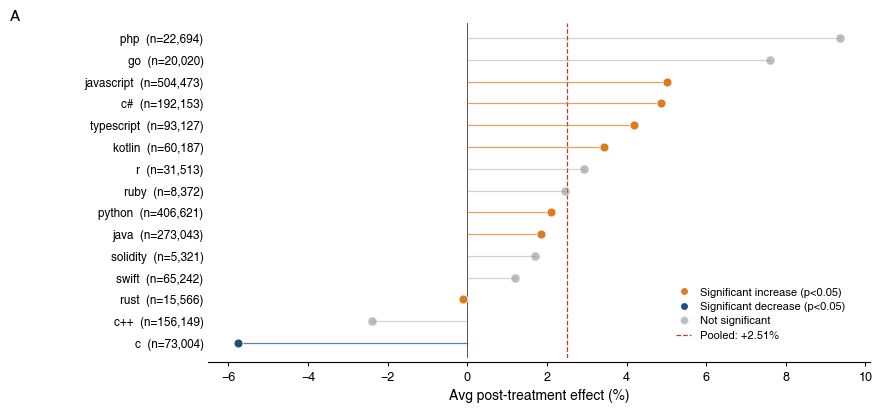

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.formula.api as smf
from scipy.stats import linregress
from matplotlib.lines import Line2D

# ═══════════════════════════════════════════
# 공통 컬러 팔레트 (다른 figure들과 통일)
# ═══════════════════════════════════════════
PALETTE = {
    'primary':    '#1f4e79',   # Significant decrease
    'accent':     '#E07A1F',   # Significant increase
    'event':      '#C0392B',   # Pooled reference
    'neutral':    '#888888',   # Not significant
}



# % 변환 함수
def beta_to_pct(beta):
    return (np.exp(beta) - 1) * 100

# ═══════════════════════════════════════════
# 1. 언어별 효과 요약 테이블 (원본 그대로)
# ═══════════════════════════════════════════
print("="*70)
print("언어별 효과 요약 — 리뷰어 응답용 테이블")
print("="*70)

lang_summary = []
for lang in ev_lang_df['language'].unique():
    sub = ev_lang_df[ev_lang_df['language'] == lang].dropna(subset=['coef'])

    pre  = sub[sub['event_bin'] < 0]
    post = sub[sub['event_bin'] > 0]

    if len(pre) < 3 or len(post) < 3:
        continue

    res_pre  = linregress(pre['event_bin'],  pre['coef'])
    res_post = linregress(post['event_bin'], post['coef'])
    post_avg = post['coef'].mean()
    final_β  = post['coef'].iloc[-1]

    lang_summary.append({
        'language':         lang,
        'n_func':           df[df['language'] == lang].shape[0],
        'pre_slope':        res_pre.slope,
        'pre_p':            res_pre.pvalue,
        'post_slope':       res_post.slope,
        'post_p':           res_post.pvalue,
        'avg_effect':       post_avg,
        'avg_effect_pct':   beta_to_pct(post_avg),
        'final_effect_pct': beta_to_pct(final_β),
    })

ldf = pd.DataFrame(lang_summary).sort_values('avg_effect', ascending=False)

print("\n[언어별 효과 — 평균 효과 큰 순]")
print(ldf[['language', 'n_func', 'pre_p', 'post_slope', 'post_p',
           'avg_effect_pct', 'final_effect_pct']].to_string(index=False))

# ═══════════════════════════════════════════
# 2. Leave-One-Out 분석 (원본 그대로)
# ═══════════════════════════════════════════
print("\n" + "="*70)
print("Leave-One-Out: 각 언어 빼고 통합 결과 재추정")
print("="*70)

loo_results = []
formula_pool = (f'{TARGET} ~ C(event_bin, Treatment(reference={REF_BIN}))'
                f' + C(language)')

for excl_lang in weekly_clean['language'].unique():
    sub = weekly_clean[weekly_clean['language'] != excl_lang]
    try:
        m = smf.wls(formula_pool, data=sub, weights=sub['n_func']).fit(
            cov_type='cluster', cov_kwds={'groups': sub['language']},
        )
    except Exception:
        continue

    post_terms = [t for t in m.params.index
                  if 'C(event_bin' in t and
                  int(t.split('T.')[1].split(']')[0]) > 0]
    post_betas = [m.params[t] for t in post_terms]

    loo_results.append({
        'excluded':       excl_lang,
        'avg_effect':     np.mean(post_betas),
        'avg_effect_pct': beta_to_pct(np.mean(post_betas)),
    })

loo_df = pd.DataFrame(loo_results).sort_values('avg_effect_pct')

# 전체 표본 결과
full_post_terms = [t for t in m_pool.params.index
                   if 'C(event_bin' in t and
                   int(t.split('T.')[1].split(']')[0]) > 0]
full_avg = np.mean([m_pool.params[t] for t in full_post_terms])
full_pct = beta_to_pct(full_avg)

print(f"\n전체 표본: {full_pct:+.2f}%")
print(f"\n각 언어 제외 시 결과:")
print(loo_df[['excluded', 'avg_effect_pct']].to_string(index=False))
print(f"\n변동 폭: {loo_df['avg_effect_pct'].min():.2f}% ~ "
      f"{loo_df['avg_effect_pct'].max():.2f}%")
print(f"전체 대비: "
      f"{(loo_df['avg_effect_pct'].max() - loo_df['avg_effect_pct'].min()):.2f}%p")

# ═══════════════════════════════════════════
# 3. 시각화 — 2-panel forest plot
# ═══════════════════════════════════════════
print("\n" + "="*70)
print("그림 생성")
print("="*70)

# 카테고리 분류 — 통합 팔레트
def categorize(row):
    if row['post_p'] >= 0.05:
        return PALETTE['neutral']
    elif row['post_slope'] > 0:
        return PALETTE['accent']
    else:
        return PALETTE['primary']

ldf['color'] = ldf.apply(categorize, axis=1)
ldf['alpha'] = ldf['color'].apply(lambda c: 0.55 if c == PALETTE['neutral'] else 1.0)

# Figure
n_lang = len(ldf)
fig_h  = max(3.5, 0.28 * n_lang)
fig, ax = plt.subplots(figsize=(9.0, fig_h))

# ───────────────────────────────────────────
# (A) Language-specific effects — lollipop
# ───────────────────────────────────────────
sorted_eff = ldf.sort_values('avg_effect_pct').reset_index(drop=True)

# 0 reference
ax.axvline(0, color='#333', lw=0.6, zorder=1)
# Pooled reference
ax.axvline(full_pct, color=PALETTE['event'], lw=0.9, ls='--', zorder=1)

for i, row in sorted_eff.iterrows():
    ax.plot([0, row['avg_effect_pct']], [i, i],
            color=row['color'], lw=0.9, alpha=row['alpha']*0.7, zorder=2)
    ax.scatter(row['avg_effect_pct'], i, s=42,
               facecolor=row['color'], edgecolor='white',
               linewidth=0.6, alpha=row['alpha'], zorder=3)

ax.set_yticks(np.arange(len(sorted_eff)))
ax.set_yticklabels([f"{r['language']}  (n={r['n_func']:,})"
                    for _, r in sorted_eff.iterrows()], fontsize=8.5)

ax.set_xlabel('Avg post-treatment effect (%)')
ax.text(-0.30, 1.04, 'A', transform=ax.transAxes,
        fontsize=11, fontweight='bold', va='top', ha='left')

# 범례
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['accent'],
           markersize=6, label='Significant increase (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['primary'],
           markersize=6, label='Significant decrease (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['neutral'],
           markersize=6, alpha=0.55, label='Not significant'),
    Line2D([0],[0], color=PALETTE['event'], lw=0.9, ls='--',
           label=f'Pooled: {full_pct:+.2f}%'),
]
ax.legend(handles=legend_elements,
          loc='lower right', bbox_to_anchor=(0.98, 0.02),
          handlelength=1.4, borderpad=0.5, labelspacing=0.4)

for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_position(('outward', 3))
ax.tick_params(axis='y', length=0)
ax.set_ylim(-0.7, len(sorted_eff) - 0.3)



for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_position(('outward', 3))
ax.tick_params(axis='y', length=0)


plt.tight_layout()
plt.show()

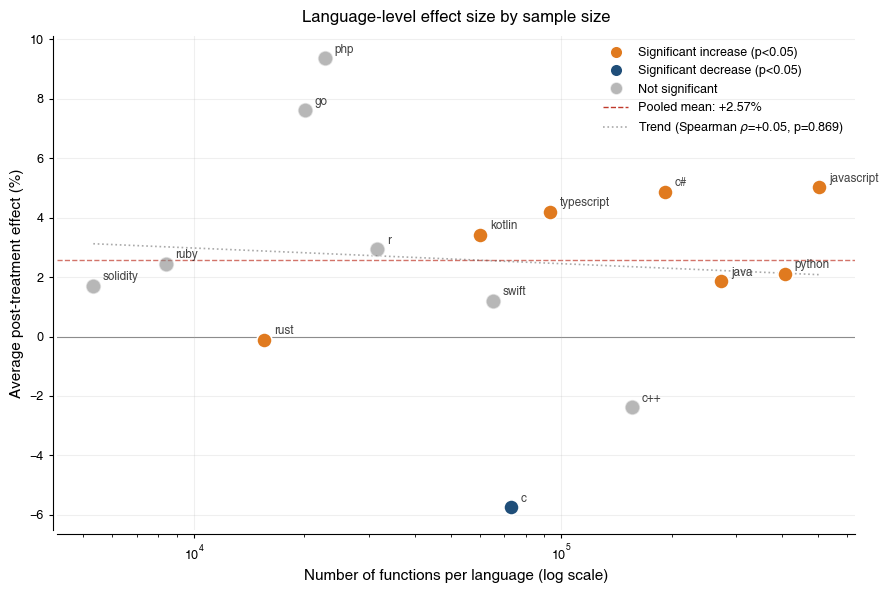

Sample size vs. effect 상관 분석
Spearman ρ:  +0.0464 (p=0.8695)
Pearson r:   -0.0863

log(n) ~ effect 회귀:
  slope:     -0.5262
  intercept: +5.0813
  R²:        0.0074

✅ 표본 크기와 효과 크기는 상관 거의 없음
   → 결과가 특정 언어(특히 대형 언어)에 좌우되지 않음


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.formula.api as smf
from scipy.stats import linregress, spearmanr
from matplotlib.lines import Line2D



# ═══════════════════════════════════════════
# 공통 컬러 팔레트
# ═══════════════════════════════════════════
PALETTE = {
    'primary':    '#1f4e79',   # Significant decrease
    'accent':     '#E07A1F',   # Significant increase
    'event':      '#C0392B',   # Pooled reference
    'neutral':    '#888888',   # Not significant
}

def beta_to_pct(beta):
    return (np.exp(beta) - 1) * 100

# ═══════════════════════════════════════════
# 1. 언어별 효과 요약 (기존 코드와 동일)
# ═══════════════════════════════════════════
lang_summary = []
for lang in ev_lang_df['language'].unique():
    sub = ev_lang_df[ev_lang_df['language'] == lang].dropna(subset=['coef'])
    pre  = sub[sub['event_bin'] < 0]
    post = sub[sub['event_bin'] > 0]
    if len(pre) < 3 or len(post) < 3:
        continue
    res_pre  = linregress(pre['event_bin'],  pre['coef'])
    res_post = linregress(post['event_bin'], post['coef'])
    post_avg = post['coef'].mean()
    final_β  = post['coef'].iloc[-1]
    lang_summary.append({
        'language':         lang,
        'n_func':           df[df['language'] == lang].shape[0],
        'pre_slope':        res_pre.slope,
        'pre_p':            res_pre.pvalue,
        'post_slope':       res_post.slope,
        'post_p':           res_post.pvalue,
        'avg_effect':       post_avg,
        'avg_effect_pct':   beta_to_pct(post_avg),
        'final_effect_pct': beta_to_pct(final_β),
    })

ldf = pd.DataFrame(lang_summary)

# 카테고리 분류
def categorize(row):
    if row['post_p'] >= 0.05:
        return PALETTE['neutral']
    elif row['post_slope'] > 0:
        return PALETTE['accent']
    else:
        return PALETTE['primary']

ldf['color'] = ldf.apply(categorize, axis=1)
ldf['alpha'] = ldf['color'].apply(lambda c: 0.6 if c == PALETTE['neutral'] else 1.0)

# Pooled 평균
full_pct = ldf['avg_effect_pct'].mean()  # 또는 m_pool에서 가져와도 됨

# ═══════════════════════════════════════════
# 2. Scatter plot
# ═══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))

# ───── 기준선 ─────
ax.axhline(0, color='#333', lw=0.8, alpha=0.6, zorder=1)
ax.axhline(full_pct, color=PALETTE['event'], lw=1.0, ls='--',
           alpha=0.7, zorder=1,
           label=f'Pooled mean: {full_pct:+.2f}%')

# ───── Scatter points ─────
for _, row in ldf.iterrows():
    ax.scatter(
        row['n_func'], row['avg_effect_pct'],
        s=120, facecolor=row['color'], edgecolor='white',
        linewidth=1.2, alpha=row['alpha'], zorder=3,
    )

# ───── 라벨 표시 (모든 언어) ─────
for _, row in ldf.iterrows():
    # 위치 조정: 점 오른쪽 약간 위
    ax.annotate(
        row['language'],
        xy=(row['n_func'], row['avg_effect_pct']),
        xytext=(7, 4), textcoords='offset points',
        fontsize=8.5, alpha=0.85,
        color='#222',
    )

# ───── x축 log 스케일 ─────
ax.set_xscale('log')

# ───── 추세선 (선택) — log(n) vs effect ─────
# 상관관계 검정
log_n = np.log10(ldf['n_func'])
rho, p_corr = spearmanr(ldf['n_func'], ldf['avg_effect_pct'])

# LOWESS 또는 OLS 추세선
res_trend = linregress(log_n, ldf['avg_effect_pct'])
x_line = np.logspace(log_n.min(), log_n.max(), 100)
y_line = res_trend.slope * np.log10(x_line) + res_trend.intercept
ax.plot(x_line, y_line, color='#555', lw=1.2, alpha=0.5,
        ls=':', zorder=2,
        label=f'Trend (Spearman ρ={rho:+.2f}, p={p_corr:.3f})')

# ───── 스타일 ─────
ax.set_xlabel('Number of functions per language (log scale)', fontsize=11)
ax.set_ylabel('Average post-treatment effect (%)', fontsize=11)
ax.set_title('Language-level effect size by sample size', fontsize=12, pad=10)

for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['bottom'].set_position(('outward', 3))
ax.spines['left'].set_position(('outward', 3))

ax.grid(alpha=0.2, zorder=0)

# ───── 범례 ─────
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['accent'],
           markersize=9, markeredgecolor='white', markeredgewidth=1,
           label='Significant increase (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['primary'],
           markersize=9, markeredgecolor='white', markeredgewidth=1,
           label='Significant decrease (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['neutral'],
           markersize=9, markeredgecolor='white', markeredgewidth=1,
           alpha=0.6, label='Not significant'),
    Line2D([0],[0], color=PALETTE['event'], lw=1.0, ls='--',
           label=f'Pooled mean: {full_pct:+.2f}%'),
    Line2D([0],[0], color='#555', lw=1.2, ls=':', alpha=0.5,
           label=f'Trend (Spearman $\\rho$={rho:+.2f}, p={p_corr:.3f})'),
]
ax.legend(handles=legend_elements, loc='best',
          fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════
# 진단 출력
# ═══════════════════════════════════════════
print("="*60)
print("Sample size vs. effect 상관 분석")
print("="*60)
print(f"Spearman ρ:  {rho:+.4f} (p={p_corr:.4f})")
print(f"Pearson r:   {np.corrcoef(log_n, ldf['avg_effect_pct'])[0,1]:+.4f}")
print(f"\nlog(n) ~ effect 회귀:")
print(f"  slope:     {res_trend.slope:+.4f}")
print(f"  intercept: {res_trend.intercept:+.4f}")
print(f"  R²:        {res_trend.rvalue**2:.4f}")

if abs(rho) < 0.3:
    print("\n✅ 표본 크기와 효과 크기는 상관 거의 없음")
    print("   → 결과가 특정 언어(특히 대형 언어)에 좌우되지 않음")
elif abs(rho) > 0.5:
    print(f"\n⚠️ 강한 상관 (ρ={rho:+.2f})")
    if rho > 0:
        print("   → 큰 언어일수록 효과 큼 (LLM 친화도와 관련?)")
    else:
        print("   → 작은 언어일수록 효과 큼 (이상치 영향?)")

분석 데이터: 3,365개 행, 19개 언어
기간: -104 ~ 155주

Pooled ITS (HAC SE, 언어 고정효과)
  Level change: -0.072%
  Slope change: +0.0301%/week
  최종 누적 (155주): +4.70%

언어별 ITS
[SKIP] fortran: n_obs=2 < 30
[SKIP] objective-c: n_obs=3 < 30

언어별 ITS 결과 (n=17):
  language  n_func  level_change_pct  level_change_p  slope_change_pct  slope_change_p  final_effect_pct
       php   22694          1.435158    3.265121e-01          0.073963    2.286775e-03         13.752008
      ruby    8372          0.801372    6.517674e-01          0.045579    3.945389e-01          8.178629
javascript  504473          0.487215    8.380838e-03          0.042683    1.874436e-26          7.358604
         r   31513         -1.889467    6.892375e-02          0.052020    6.292394e-03          6.346685
        c#  192153         -0.717274    4.632760e-02          0.044077    8.253824e-11          6.301205
        go   20020         -1.313053    3.132609e-01          0.043962    1.044806e-01          5.644448
typescript   93127        

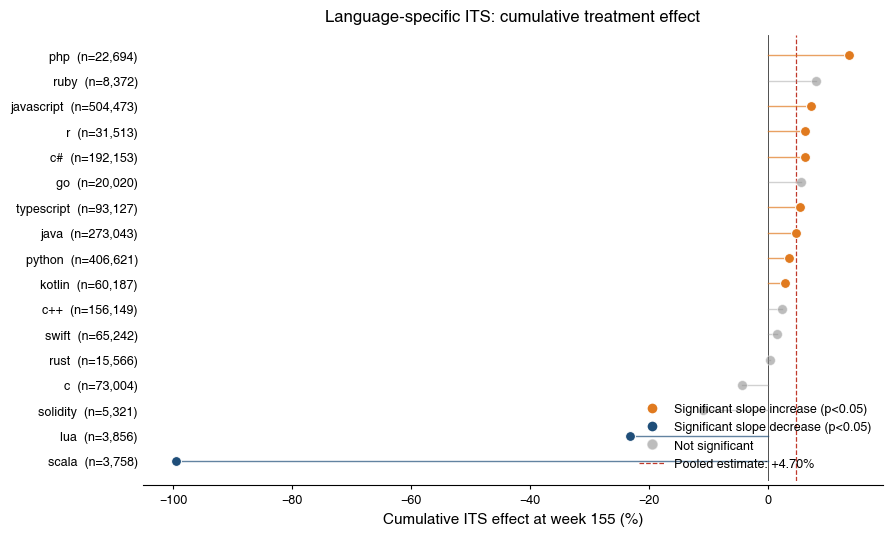

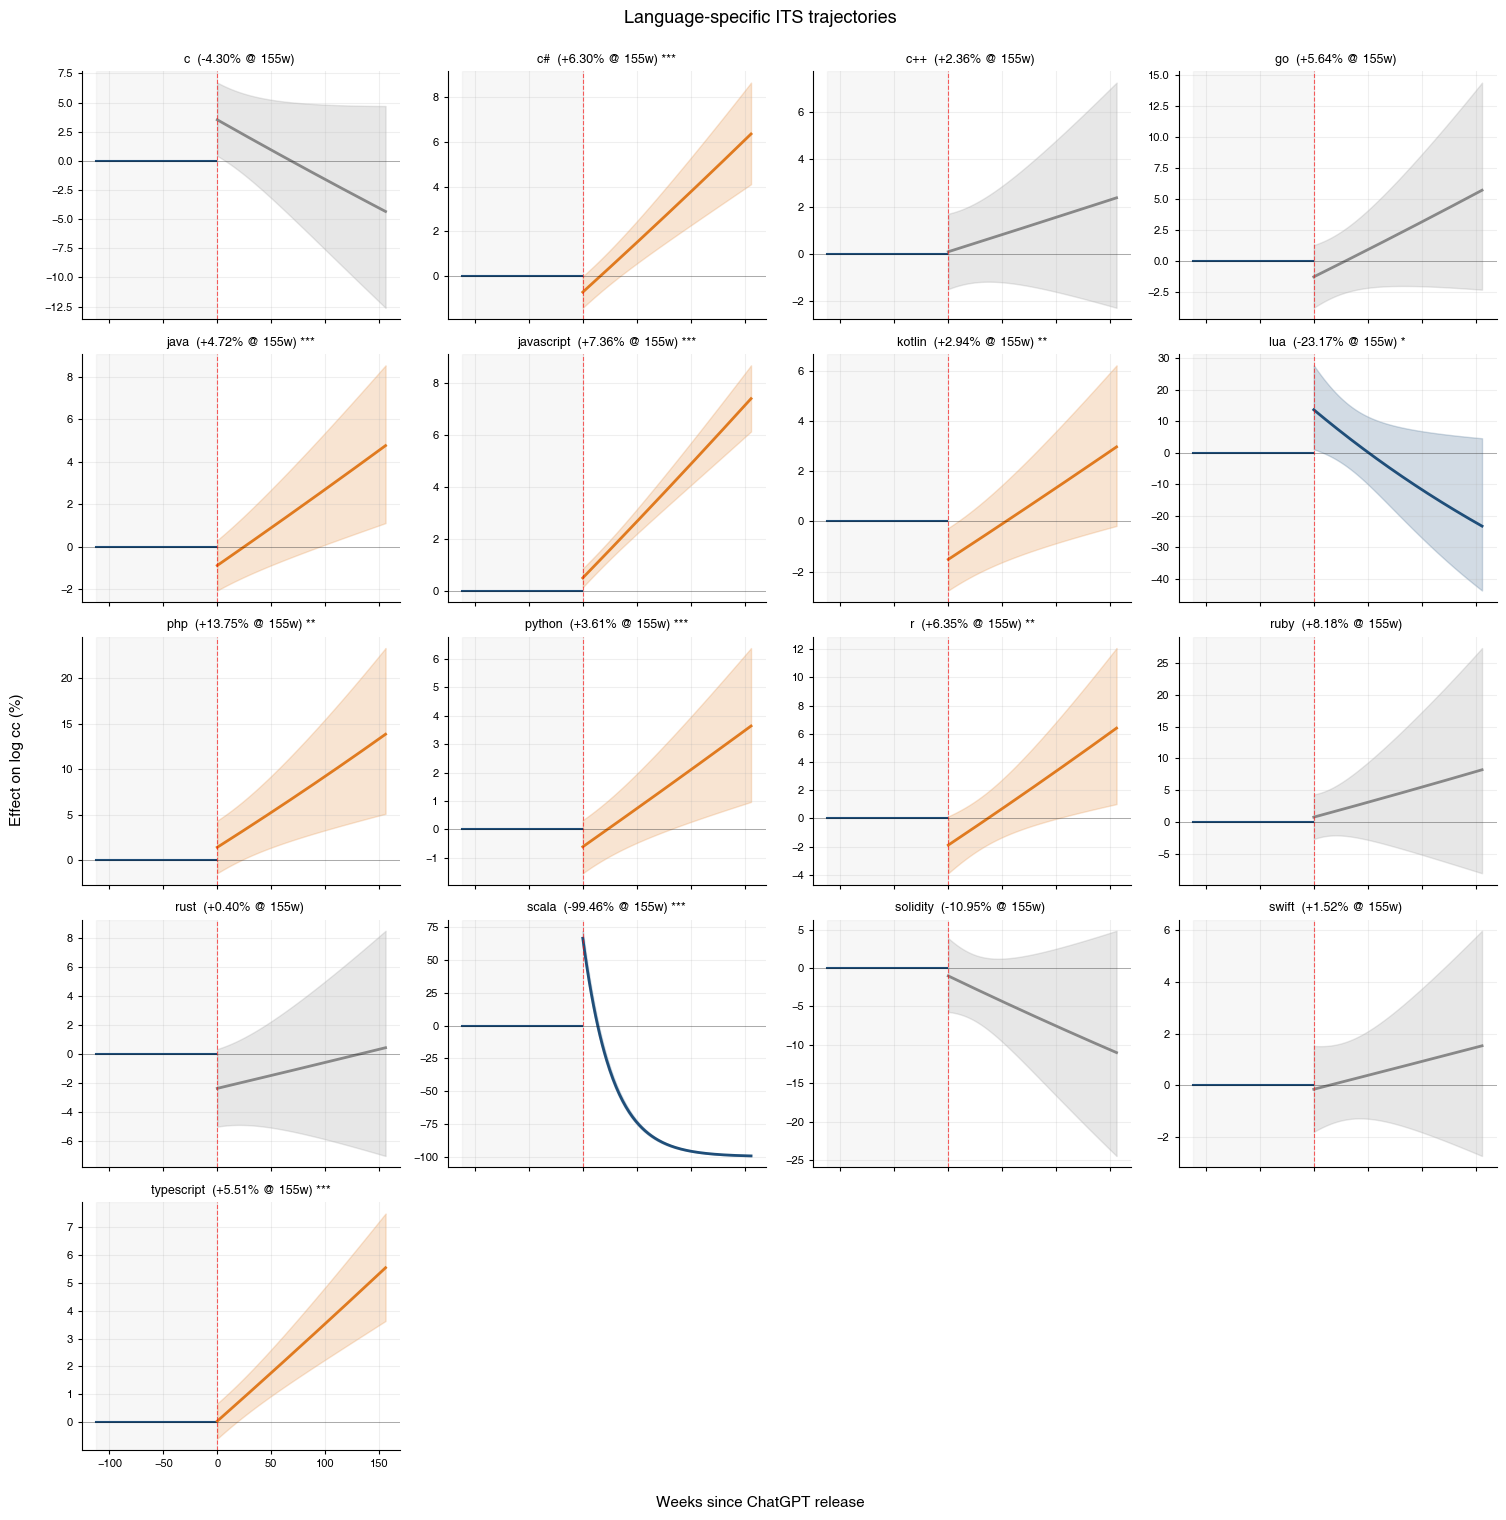


요약 통계
분석된 언어 수: 17

Slope change 분포:
  유의한 양수 (p<0.05): 8
  유의한 음수 (p<0.05): 2
  비유의 (p>=0.05):     7

누적 효과 분포 (155주 시점):
  중앙값: +3.61%
  평균:   -4.07%
  범위:   [-99.46%, +13.75%]
  Pooled: +4.70%


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.formula.api as smf
from scipy.stats import linregress



# ═══════════════════════════════════════════
# 0. 설정 (Event Study와 동일한 기간 사용)
# ═══════════════════════════════════════════
CHATGPT_DATE = pd.Timestamp('2022-11-30')
TARGET       = 'log_cc_mean'
BIN_SIZE     = 4
MIN_BIN      = -28       # Event Study 범위와 동일
MAX_BIN      = +39

# Bin 범위를 주 단위로 변환
MIN_WEEK = MIN_BIN * BIN_SIZE   # -112
MAX_WEEK = MAX_BIN * BIN_SIZE   # +156

# ═══════════════════════════════════════════
# 1. 데이터 준비 (Event Study와 동일)
# ═══════════════════════════════════════════
df = tot_viz_df.copy()
df['creationdate'] = pd.to_datetime(df['creationdate'], format='mixed')
df = df[df['cyclomatic_complexity'] > 0].dropna(subset=['nloc']).copy()
df['log_cc'] = np.log1p(df['cyclomatic_complexity'])
df['week'] = df['creationdate'].dt.to_period('W').dt.start_time

valid = df['language'].value_counts()[lambda s: s >= 1000].index
df = df[df['language'].isin(valid)].copy()

# 주별 × 언어별 집계
weekly = df.groupby(['language', 'week']).agg(
    log_cc_mean = ('log_cc', 'mean'),
    log_cc_std  = ('log_cc', 'std'),
    n_func      = ('cyclomatic_complexity', 'count'),
).reset_index()

weekly = weekly[weekly['n_func'] >= 30].copy()
weekly['weeks_since'] = ((weekly['week'] - CHATGPT_DATE).dt.days / 7).round().astype(int)

# Event Study와 동일한 시간 범위
weekly = weekly[
    (weekly['weeks_since'] >= MIN_WEEK) &
    (weekly['weeks_since'] <= MAX_WEEK)
].copy()

# ───── ITS 핵심 변수 ─────
weekly['t']      = weekly['weeks_since']
weekly['post']   = (weekly['weeks_since'] >= 0).astype(int)
weekly['post_t'] = weekly['post'] * weekly['weeks_since']

print(f"분석 데이터: {len(weekly):,}개 행, {weekly['language'].nunique()}개 언어")
print(f"기간: {weekly['weeks_since'].min()} ~ {weekly['weeks_since'].max()}주")

def beta_to_pct(b): return (np.exp(b) - 1) * 100

# ═══════════════════════════════════════════
# 2. Pooled ITS (참고용 기준값)
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("Pooled ITS (HAC SE, 언어 고정효과)")
print("="*60)

weekly_sorted = weekly.sort_values(['language', 't']).reset_index(drop=True)
formula_pool = f'{TARGET} ~ t + post + post_t + C(language)'

m_pool = smf.wls(
    formula_pool, data=weekly_sorted, weights=weekly_sorted['n_func']
).fit(cov_type='HAC', cov_kwds={'maxlags': 8})

# Pooled 결과 추출
pool_level_pct = beta_to_pct(m_pool.params['post'])
pool_slope_pct = beta_to_pct(m_pool.params['post_t'])

# 최종 시점 누적 효과 (% 단위)
final_t = weekly['t'].max()
pool_final_log = m_pool.params['post'] + m_pool.params['post_t'] * final_t
pool_final_pct = beta_to_pct(pool_final_log)

print(f"  Level change: {pool_level_pct:+.3f}%")
print(f"  Slope change: {pool_slope_pct:+.4f}%/week")
print(f"  최종 누적 ({final_t}주): {pool_final_pct:+.2f}%")

# ═══════════════════════════════════════════
# 3. 언어별 ITS 회귀
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("언어별 ITS")
print("="*60)

its_lang_results = []
formula_lang = f'{TARGET} ~ t + post + post_t'

for lang in sorted(weekly['language'].unique()):
    sub = weekly[weekly['language'] == lang].sort_values('t').copy()
    
    if len(sub) < 30:
        print(f"[SKIP] {lang}: n_obs={len(sub)} < 30")
        continue
    
    try:
        m = smf.wls(formula_lang, data=sub, weights=sub['n_func']).fit(
            cov_type='HAC', cov_kwds={'maxlags': 8}
        )
    except Exception as e:
        print(f"[SKIP] {lang}: {e}")
        continue
    
    if m.bse.isna().any():
        print(f"[SKIP] {lang}: NaN SE")
        continue
    
    # 최종 시점 누적 효과
    final_log = m.params['post'] + m.params['post_t'] * final_t
    
    its_lang_results.append({
        'language':         lang,
        'n_func':           df[df['language'] == lang].shape[0],
        'n_obs':            len(sub),
        
        # Pre-trend
        'pre_trend':        m.params['t'],
        'pre_trend_p':      m.pvalues['t'],
        
        # Level change
        'level_change':     m.params['post'],
        'level_change_se':  m.bse['post'],
        'level_change_p':   m.pvalues['post'],
        'level_change_pct': beta_to_pct(m.params['post']),
        
        # Slope change (가장 중요)
        'slope_change':     m.params['post_t'],
        'slope_change_se':  m.bse['post_t'],
        'slope_change_p':   m.pvalues['post_t'],
        'slope_change_pct': beta_to_pct(m.params['post_t']),
        
        # 누적 효과 (최종 시점)
        'final_effect':     final_log,
        'final_effect_pct': beta_to_pct(final_log),
        
        'r_squared':        m.rsquared,
    })

its_lang_df = pd.DataFrame(its_lang_results)

# ───── 결과 테이블 출력 ─────
print(f"\n언어별 ITS 결과 (n={len(its_lang_df)}):")
print(its_lang_df[['language', 'n_func',
                   'level_change_pct', 'level_change_p',
                   'slope_change_pct', 'slope_change_p',
                   'final_effect_pct']]
      .sort_values('final_effect_pct', ascending=False)
      .to_string(index=False))

# ═══════════════════════════════════════════
# 4. Forest plot — 언어별 슬로프 변화 / 누적 효과
# ═══════════════════════════════════════════
PALETTE = {
    'primary':    '#1f4e79',   # significant decrease
    'accent':     '#E07A1F',   # significant increase
    'event':      '#C0392B',   # pooled reference
    'neutral':    '#888888',   # not significant
}

def categorize(row, p_col, beta_col):
    if row[p_col] >= 0.05:
        return PALETTE['neutral']
    elif row[beta_col] > 0:
        return PALETTE['accent']
    else:
        return PALETTE['primary']

# Forest plot: 누적 효과 기준
its_lang_df['color_final'] = its_lang_df.apply(
    lambda r: categorize(r, 'slope_change_p', 'slope_change'), axis=1
)
its_lang_df['alpha'] = its_lang_df['color_final'].apply(
    lambda c: 0.55 if c == PALETTE['neutral'] else 1.0
)

# 정렬: 누적 효과 기준
sorted_eff = its_lang_df.sort_values('final_effect_pct').reset_index(drop=True)

fig_h = max(3.5, 0.32 * len(sorted_eff))
fig, ax = plt.subplots(figsize=(9, fig_h))

# 기준선
ax.axvline(0, color='#333', lw=0.6, zorder=1)
ax.axvline(pool_final_pct, color=PALETTE['event'], lw=0.9, ls='--', zorder=1,
           label=f'Pooled: {pool_final_pct:+.2f}%')

# Lollipop
for i, row in sorted_eff.iterrows():
    ax.plot([0, row['final_effect_pct']], [i, i],
            color=row['color_final'], lw=1.0, alpha=row['alpha']*0.7, zorder=2)
    ax.scatter(row['final_effect_pct'], i, s=50,
               facecolor=row['color_final'], edgecolor='white',
               linewidth=0.7, alpha=row['alpha'], zorder=3)

ax.set_yticks(np.arange(len(sorted_eff)))
ax.set_yticklabels([f"{r['language']}  (n={r['n_func']:,})"
                    for _, r in sorted_eff.iterrows()], fontsize=9)

ax.set_xlabel(f'Cumulative ITS effect at week {final_t} (%)', fontsize=11)
ax.set_title('Language-specific ITS: cumulative treatment effect',
             fontsize=12, pad=10)

# 범례
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['accent'],
           markersize=8, markeredgecolor='white', markeredgewidth=1,
           label='Significant slope increase (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['primary'],
           markersize=8, markeredgecolor='white', markeredgewidth=1,
           label='Significant slope decrease (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['neutral'],
           markersize=8, markeredgecolor='white', markeredgewidth=1,
           alpha=0.55, label='Not significant'),
    Line2D([0],[0], color=PALETTE['event'], lw=0.9, ls='--',
           label=f'Pooled estimate: {pool_final_pct:+.2f}%'),
]
ax.legend(handles=legend_elements, loc='lower right',
          fontsize=9, frameon=False)

for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_position(('outward', 3))
ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════
# 5. 언어별 ITS 추세 그리드 (선택)
# ═══════════════════════════════════════════
languages = sorted(its_lang_df['language'].unique())
n_lang  = len(languages)
n_cols  = 4
n_rows  = (n_lang + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.0*n_rows),
                         sharex=True, sharey=False)
axes_flat = axes.flatten()

t_grid = np.arange(MIN_WEEK, MAX_WEEK + 1)

for ax, lang in zip(axes_flat, languages):
    sub = weekly[weekly['language'] == lang].sort_values('t')
    
    # 회귀 다시 (CI용)
    m = smf.wls(formula_lang, data=sub, weights=sub['n_func']).fit(
        cov_type='HAC', cov_kwds={'maxlags': 8}
    )
    
    # ITS 효과 시점별 (delta method)
    β_p, β_pt = m.params['post'], m.params['post_t']
    cov = m.cov_params()
    v_p  = cov.loc['post','post']
    v_pt = cov.loc['post_t','post_t']
    c_p_pt = cov.loc['post','post_t']
    
    eff = np.where(t_grid >= 0, β_p + β_pt * t_grid, 0.0)
    var = np.where(t_grid >= 0,
                   v_p + (t_grid**2)*v_pt + 2*t_grid*c_p_pt, 0.0)
    se  = np.sqrt(np.maximum(var, 0))
    
    eff_pct  = beta_to_pct(eff)
    ci_low   = beta_to_pct(eff - 1.96*se)
    ci_high  = beta_to_pct(eff + 1.96*se)
    
    # 색상 (forest와 일치)
    color = its_lang_df.set_index('language').loc[lang, 'color_final']
    
    # 음영
    pre_mask  = t_grid < 0
    post_mask = t_grid >= 0
    
    ax.axvspan(MIN_WEEK, 0, alpha=0.06, color='gray')
    ax.fill_between(t_grid[post_mask],
                    ci_low[post_mask], ci_high[post_mask],
                    alpha=0.2, color=color)
    ax.plot(t_grid[pre_mask],  eff_pct[pre_mask],
            '-', color='#1f4e79', lw=1.5)
    ax.plot(t_grid[post_mask], eff_pct[post_mask],
            '-', color=color, lw=2)
    
    ax.axvline(0, color='red', ls='--', alpha=0.6, lw=0.8)
    ax.axhline(0, color='black', lw=0.5, alpha=0.4)
    
    # 제목에 효과 크기 표시
    final_pct = its_lang_df.set_index('language').loc[lang, 'final_effect_pct']
    slope_p   = its_lang_df.set_index('language').loc[lang, 'slope_change_p']
    sig = '***' if slope_p<0.001 else '**' if slope_p<0.01 else '*' if slope_p<0.05 else ''
    ax.set_title(f'{lang}  ({final_pct:+.2f}% @ {final_t}w) {sig}',
                 fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.2)
    
    for s in ['top','right']: ax.spines[s].set_visible(False)

# 남은 axes 끄기
for ax in axes_flat[len(languages):]:
    ax.axis('off')

# 공통 라벨
fig.supxlabel('Weeks since ChatGPT release', fontsize=11, y=0.0)
fig.supylabel('Effect on log cc (%)', fontsize=11, x=0.0)
plt.suptitle('Language-specific ITS trajectories', fontsize=13, y=1.00)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════
# 6. 요약 통계
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("요약 통계")
print("="*60)
print(f"분석된 언어 수: {len(its_lang_df)}")
print(f"\nSlope change 분포:")
print(f"  유의한 양수 (p<0.05): {((its_lang_df['slope_change'] > 0) & (its_lang_df['slope_change_p'] < 0.05)).sum()}")
print(f"  유의한 음수 (p<0.05): {((its_lang_df['slope_change'] < 0) & (its_lang_df['slope_change_p'] < 0.05)).sum()}")
print(f"  비유의 (p>=0.05):     {(its_lang_df['slope_change_p'] >= 0.05).sum()}")
print(f"\n누적 효과 분포 ({final_t}주 시점):")
print(f"  중앙값: {its_lang_df['final_effect_pct'].median():+.2f}%")
print(f"  평균:   {its_lang_df['final_effect_pct'].mean():+.2f}%")
print(f"  범위:   [{its_lang_df['final_effect_pct'].min():+.2f}%, "
      f"{its_lang_df['final_effect_pct'].max():+.2f}%]")
print(f"  Pooled: {pool_final_pct:+.2f}%")

Pooled cumulative effect at 155w: +4.70%


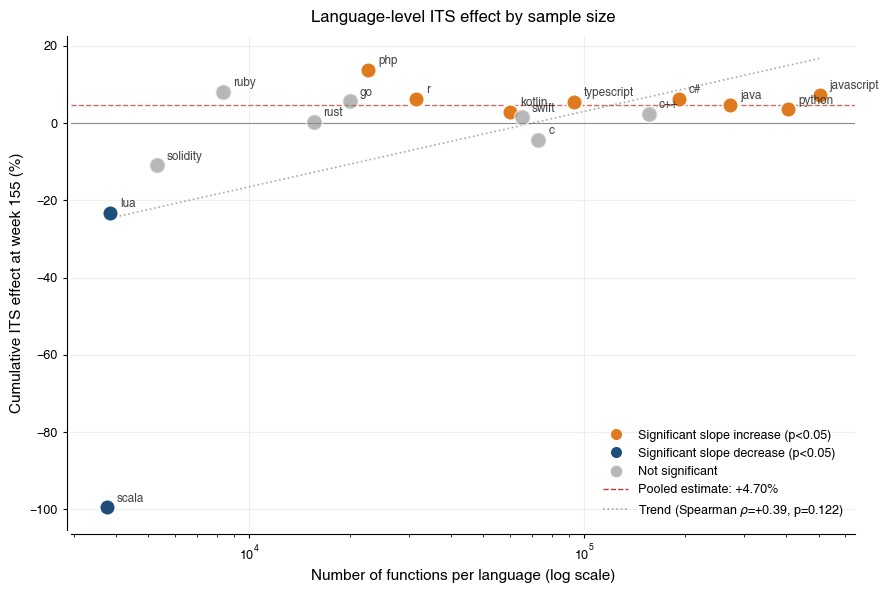

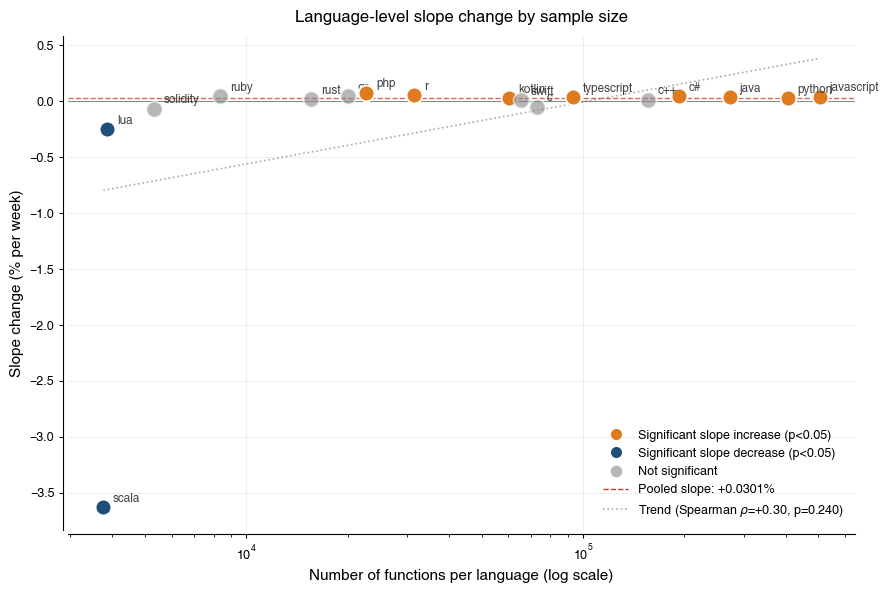

Sample size vs. ITS effect 상관 분석

[누적 효과 (155주) 기준]
  Spearman ρ:  +0.3897 (p=0.1220)
  log(n)~effect 회귀: slope=+19.533, R²=0.270

[Slope change 기준]
  Spearman ρ:  +0.3015 (p=0.2396)
  log(n)~slope 회귀: slope=+0.55440, R²=0.187

[효과 분포]
  Pooled 누적 효과:     +4.70%
  언어별 중앙값:        +3.61%
  언어별 범위:          [-99.46%, +13.75%]

[유의성 분포]
  유의한 증가: 8개
  유의한 감소: 2개
  비유의:      7개

언어별 결과 (누적 효과 큰 순)
  language  n_func  level_change_pct  level_change_p  slope_change_pct  slope_change_p  final_effect_pct
       php   22694          1.435158    3.265121e-01          0.073963    2.286775e-03         13.752008
      ruby    8372          0.801372    6.517674e-01          0.045579    3.945389e-01          8.178629
javascript  504473          0.487215    8.380838e-03          0.042683    1.874436e-26          7.358604
         r   31513         -1.889467    6.892375e-02          0.052020    6.292394e-03          6.346685
        c#  192153         -0.717274    4.632760e-02          0.044077    8.25

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.formula.api as smf
from scipy.stats import spearmanr, linregress
from matplotlib.lines import Line2D


# ═══════════════════════════════════════════
# 컬러 팔레트
# ═══════════════════════════════════════════
PALETTE = {
    'primary':    '#1f4e79',   # significant decrease
    'accent':     '#E07A1F',   # significant increase
    'event':      '#C0392B',   # pooled reference
    'neutral':    '#888888',   # not significant
}

def beta_to_pct(b): return (np.exp(b) - 1) * 100

# ═══════════════════════════════════════════
# 0. 설정
# ═══════════════════════════════════════════
CHATGPT_DATE = pd.Timestamp('2022-11-30')
TARGET       = 'log_cc_mean'
BIN_SIZE     = 4
MIN_BIN      = -28
MAX_BIN      = +39
MIN_WEEK     = MIN_BIN * BIN_SIZE
MAX_WEEK     = MAX_BIN * BIN_SIZE

# ═══════════════════════════════════════════
# 1. 데이터 준비
# ═══════════════════════════════════════════
df = tot_viz_df.copy()
df['creationdate'] = pd.to_datetime(df['creationdate'], format='mixed')
df = df[df['cyclomatic_complexity'] > 0].dropna(subset=['nloc']).copy()
df['log_cc'] = np.log1p(df['cyclomatic_complexity'])
df['week']   = df['creationdate'].dt.to_period('W').dt.start_time

valid = df['language'].value_counts()[lambda s: s >= 1000].index
df = df[df['language'].isin(valid)].copy()

weekly = df.groupby(['language', 'week']).agg(
    log_cc_mean = ('log_cc', 'mean'),
    n_func      = ('cyclomatic_complexity', 'count'),
).reset_index()
weekly = weekly[weekly['n_func'] >= 30].copy()
weekly['weeks_since'] = ((weekly['week'] - CHATGPT_DATE).dt.days / 7).round().astype(int)
weekly = weekly[(weekly['weeks_since'] >= MIN_WEEK) &
                (weekly['weeks_since'] <= MAX_WEEK)].copy()

weekly['t']      = weekly['weeks_since']
weekly['post']   = (weekly['weeks_since'] >= 0).astype(int)
weekly['post_t'] = weekly['post'] * weekly['weeks_since']

# ═══════════════════════════════════════════
# 2. Pooled ITS (참고용)
# ═══════════════════════════════════════════
weekly_sorted = weekly.sort_values(['language', 't']).reset_index(drop=True)
m_pool = smf.wls(
    f'{TARGET} ~ t + post + post_t + C(language)',
    data=weekly_sorted, weights=weekly_sorted['n_func']
).fit(cov_type='HAC', cov_kwds={'maxlags': 8})

final_t = weekly['t'].max()
pool_final_log = m_pool.params['post'] + m_pool.params['post_t'] * final_t
pool_final_pct = beta_to_pct(pool_final_log)

print(f"Pooled cumulative effect at {final_t}w: {pool_final_pct:+.2f}%")

# ═══════════════════════════════════════════
# 3. 언어별 ITS
# ═══════════════════════════════════════════
its_lang_results = []
for lang in sorted(weekly['language'].unique()):
    sub = weekly[weekly['language'] == lang].sort_values('t').copy()
    if len(sub) < 30:
        continue
    try:
        m = smf.wls(f'{TARGET} ~ t + post + post_t',
                    data=sub, weights=sub['n_func']).fit(
            cov_type='HAC', cov_kwds={'maxlags': 8}
        )
    except Exception:
        continue
    if m.bse.isna().any():
        continue
    
    final_log = m.params['post'] + m.params['post_t'] * final_t
    
    its_lang_results.append({
        'language':          lang,
        'n_func':            df[df['language'] == lang].shape[0],
        'pre_trend':         m.params['t'],
        'pre_trend_p':       m.pvalues['t'],
        'level_change':      m.params['post'],
        'level_change_p':    m.pvalues['post'],
        'level_change_pct':  beta_to_pct(m.params['post']),
        'slope_change':      m.params['post_t'],
        'slope_change_se':   m.bse['post_t'],
        'slope_change_p':    m.pvalues['post_t'],
        'slope_change_pct':  beta_to_pct(m.params['post_t']),
        'final_effect_pct':  beta_to_pct(final_log),
    })

its_lang_df = pd.DataFrame(its_lang_results)

# 색상 분류 (slope change 기준)
def categorize(row):
    if row['slope_change_p'] >= 0.05:
        return PALETTE['neutral']
    elif row['slope_change'] > 0:
        return PALETTE['accent']
    else:
        return PALETTE['primary']

its_lang_df['color'] = its_lang_df.apply(categorize, axis=1)
its_lang_df['alpha'] = its_lang_df['color'].apply(
    lambda c: 0.6 if c == PALETTE['neutral'] else 1.0
)

# ═══════════════════════════════════════════
# 4. Scatter plot — 표본 크기 vs 누적 효과
# ═══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))

# ───── 기준선 ─────
ax.axhline(0, color='#333', lw=0.8, alpha=0.6, zorder=1)
ax.axhline(pool_final_pct, color=PALETTE['event'], lw=1.0, ls='--',
           alpha=0.75, zorder=1)

# ───── Scatter points ─────
for _, row in its_lang_df.iterrows():
    ax.scatter(
        row['n_func'], row['final_effect_pct'],
        s=130, facecolor=row['color'], edgecolor='white',
        linewidth=1.3, alpha=row['alpha'], zorder=3,
    )

# ───── 라벨 (모든 언어) ─────
for _, row in its_lang_df.iterrows():
    ax.annotate(
        row['language'],
        xy=(row['n_func'], row['final_effect_pct']),
        xytext=(7, 4), textcoords='offset points',
        fontsize=8.5, alpha=0.85, color='#222',
    )

# ───── log 스케일 + 추세선 ─────
ax.set_xscale('log')

log_n = np.log10(its_lang_df['n_func'])
rho, p_corr = spearmanr(its_lang_df['n_func'], its_lang_df['final_effect_pct'])
res_trend = linregress(log_n, its_lang_df['final_effect_pct'])
x_line = np.logspace(log_n.min(), log_n.max(), 100)
y_line = res_trend.slope * np.log10(x_line) + res_trend.intercept
ax.plot(x_line, y_line, color='#555', lw=1.2, alpha=0.5, ls=':', zorder=2)

# ───── 스타일 ─────
ax.set_xlabel('Number of functions per language (log scale)', fontsize=11)
ax.set_ylabel(f'Cumulative ITS effect at week {final_t} (%)', fontsize=11)
ax.set_title('Language-level ITS effect by sample size',
             fontsize=12, pad=10)

for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['bottom'].set_position(('outward', 3))
ax.spines['left'].set_position(('outward', 3))
ax.grid(alpha=0.2, zorder=0)

# ───── 범례 ─────
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['accent'],
           markersize=9, markeredgecolor='white', markeredgewidth=1,
           label='Significant slope increase (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['primary'],
           markersize=9, markeredgecolor='white', markeredgewidth=1,
           label='Significant slope decrease (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['neutral'],
           markersize=9, markeredgecolor='white', markeredgewidth=1,
           alpha=0.6, label='Not significant'),
    Line2D([0],[0], color=PALETTE['event'], lw=1.0, ls='--',
           label=f'Pooled estimate: {pool_final_pct:+.2f}%'),
    Line2D([0],[0], color='#555', lw=1.2, ls=':', alpha=0.5,
           label=f'Trend (Spearman $\\rho$={rho:+.2f}, p={p_corr:.3f})'),
]
ax.legend(handles=legend_elements, loc='best',
          fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════
# 5. (추가) Slope change 버전 — y축만 다름
# ═══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 6))

pool_slope_pct = beta_to_pct(m_pool.params['post_t'])

ax.axhline(0, color='#333', lw=0.8, alpha=0.6, zorder=1)
ax.axhline(pool_slope_pct, color=PALETTE['event'], lw=1.0, ls='--',
           alpha=0.75, zorder=1)

for _, row in its_lang_df.iterrows():
    ax.scatter(
        row['n_func'], row['slope_change_pct'],
        s=130, facecolor=row['color'], edgecolor='white',
        linewidth=1.3, alpha=row['alpha'], zorder=3,
    )
    ax.annotate(
        row['language'],
        xy=(row['n_func'], row['slope_change_pct']),
        xytext=(7, 4), textcoords='offset points',
        fontsize=8.5, alpha=0.85, color='#222',
    )

ax.set_xscale('log')

rho2, p_corr2 = spearmanr(its_lang_df['n_func'], its_lang_df['slope_change_pct'])
res_trend2 = linregress(log_n, its_lang_df['slope_change_pct'])
y_line2 = res_trend2.slope * np.log10(x_line) + res_trend2.intercept
ax.plot(x_line, y_line2, color='#555', lw=1.2, alpha=0.5, ls=':', zorder=2)

ax.set_xlabel('Number of functions per language (log scale)', fontsize=11)
ax.set_ylabel('Slope change (% per week)', fontsize=11)
ax.set_title('Language-level slope change by sample size',
             fontsize=12, pad=10)

for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['bottom'].set_position(('outward', 3))
ax.spines['left'].set_position(('outward', 3))
ax.grid(alpha=0.2, zorder=0)

legend_elements_2 = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['accent'],
           markersize=9, markeredgecolor='white', markeredgewidth=1,
           label='Significant slope increase (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['primary'],
           markersize=9, markeredgecolor='white', markeredgewidth=1,
           label='Significant slope decrease (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['neutral'],
           markersize=9, markeredgecolor='white', markeredgewidth=1,
           alpha=0.6, label='Not significant'),
    Line2D([0],[0], color=PALETTE['event'], lw=1.0, ls='--',
           label=f'Pooled slope: {pool_slope_pct:+.4f}%'),
    Line2D([0],[0], color='#555', lw=1.2, ls=':', alpha=0.5,
           label=f'Trend (Spearman $\\rho$={rho2:+.2f}, p={p_corr2:.3f})'),
]
ax.legend(handles=legend_elements_2, loc='best',
          fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('its_language_scatter_slope.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

# ═══════════════════════════════════════════
# 6. 진단 출력
# ═══════════════════════════════════════════
print("="*60)
print("Sample size vs. ITS effect 상관 분석")
print("="*60)
print(f"\n[누적 효과 ({final_t}주) 기준]")
print(f"  Spearman ρ:  {rho:+.4f} (p={p_corr:.4f})")
print(f"  log(n)~effect 회귀: slope={res_trend.slope:+.3f}, R²={res_trend.rvalue**2:.3f}")

print(f"\n[Slope change 기준]")
print(f"  Spearman ρ:  {rho2:+.4f} (p={p_corr2:.4f})")
print(f"  log(n)~slope 회귀: slope={res_trend2.slope:+.5f}, R²={res_trend2.rvalue**2:.3f}")

print(f"\n[효과 분포]")
print(f"  Pooled 누적 효과:     {pool_final_pct:+.2f}%")
print(f"  언어별 중앙값:        {its_lang_df['final_effect_pct'].median():+.2f}%")
print(f"  언어별 범위:          [{its_lang_df['final_effect_pct'].min():+.2f}%, "
      f"{its_lang_df['final_effect_pct'].max():+.2f}%]")

print(f"\n[유의성 분포]")
n_sig_pos = ((its_lang_df['slope_change'] > 0) & (its_lang_df['slope_change_p'] < 0.05)).sum()
n_sig_neg = ((its_lang_df['slope_change'] < 0) & (its_lang_df['slope_change_p'] < 0.05)).sum()
n_nonsig  = (its_lang_df['slope_change_p'] >= 0.05).sum()
print(f"  유의한 증가: {n_sig_pos}개")
print(f"  유의한 감소: {n_sig_neg}개")
print(f"  비유의:      {n_nonsig}개")

# ═══════════════════════════════════════════
# 7. 결과 테이블
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("언어별 결과 (누적 효과 큰 순)")
print("="*60)
print(its_lang_df[['language', 'n_func',
                   'level_change_pct', 'level_change_p',
                   'slope_change_pct', 'slope_change_p',
                   'final_effect_pct']]
      .sort_values('final_effect_pct', ascending=False)
      .to_string(index=False))

포함 언어 (13): ['c', 'c#', 'c++', 'go', 'java', 'javascript', 'kotlin', 'php', 'python', 'r', 'rust', 'swift', 'typescript']
제외 언어 (6): ['fortran', 'lua', 'objective-c', 'ruby', 'scala', 'solidity']
기준: pre>=50, post>=50주
분석 데이터: 3,103개 행

Pooled ITS (HAC SE, 언어 고정효과)
  Level change: -0.078%
  Slope change: +0.0301%/week
  최종 누적 (156주): +4.73%

언어별 ITS

언어별 ITS 결과 (n=13):
  language  n_func  level_change_pct  level_change_p  slope_change_pct  slope_change_p  final_effect_pct
       php   22694          1.435158        0.326512          0.073963    2.286775e-03         13.836143
javascript  504473          0.487215        0.008381          0.042683    1.874436e-26          7.404427
         r   31513         -1.889467        0.068924          0.052020    6.292394e-03          6.402006
        c#  192153         -0.717274        0.046328          0.044077    8.253824e-11          6.348060
        go   20020         -1.313053        0.313261          0.043962    1.044806e-01          5.69089

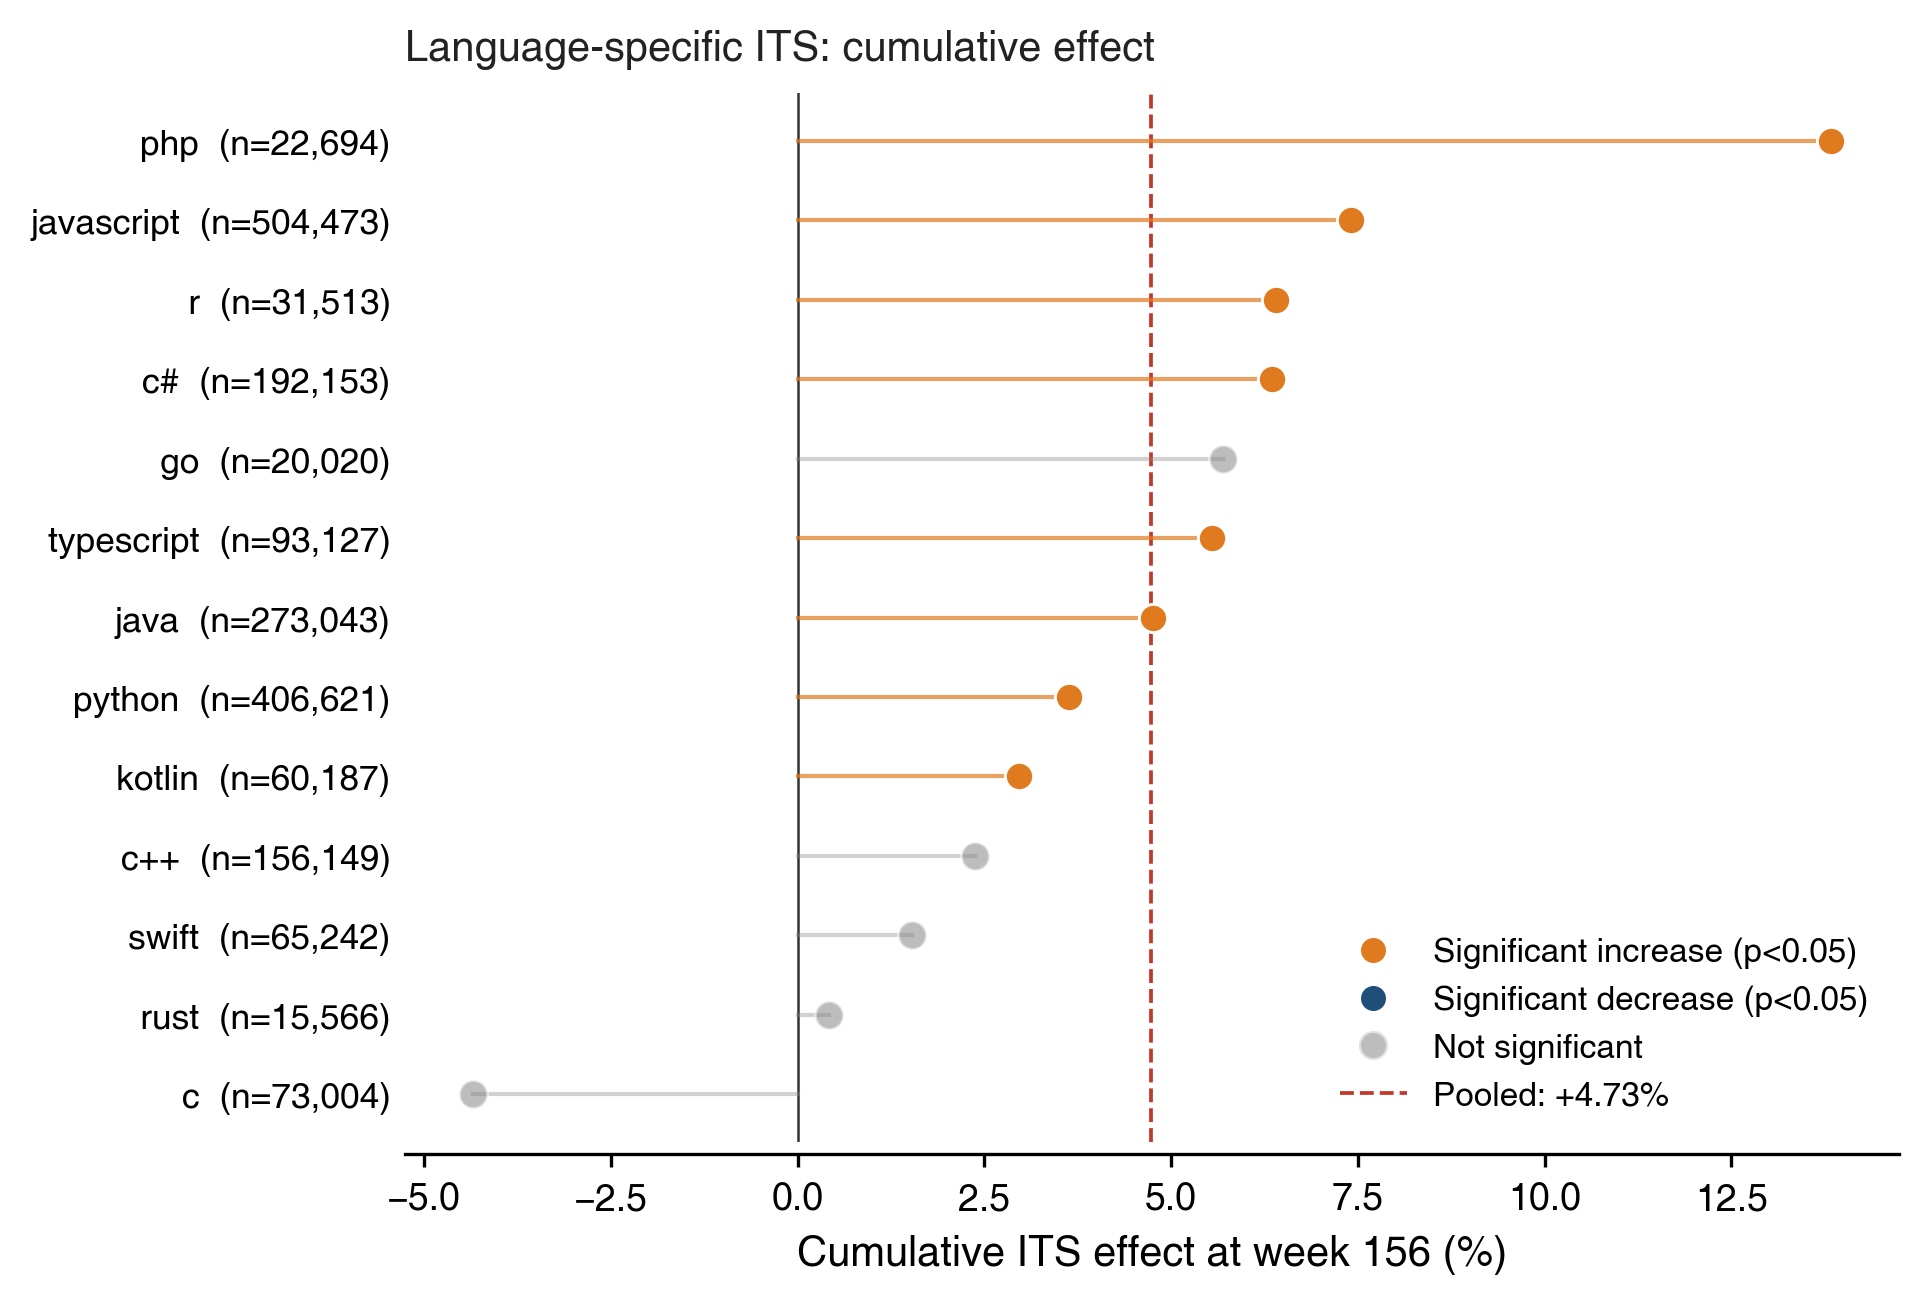

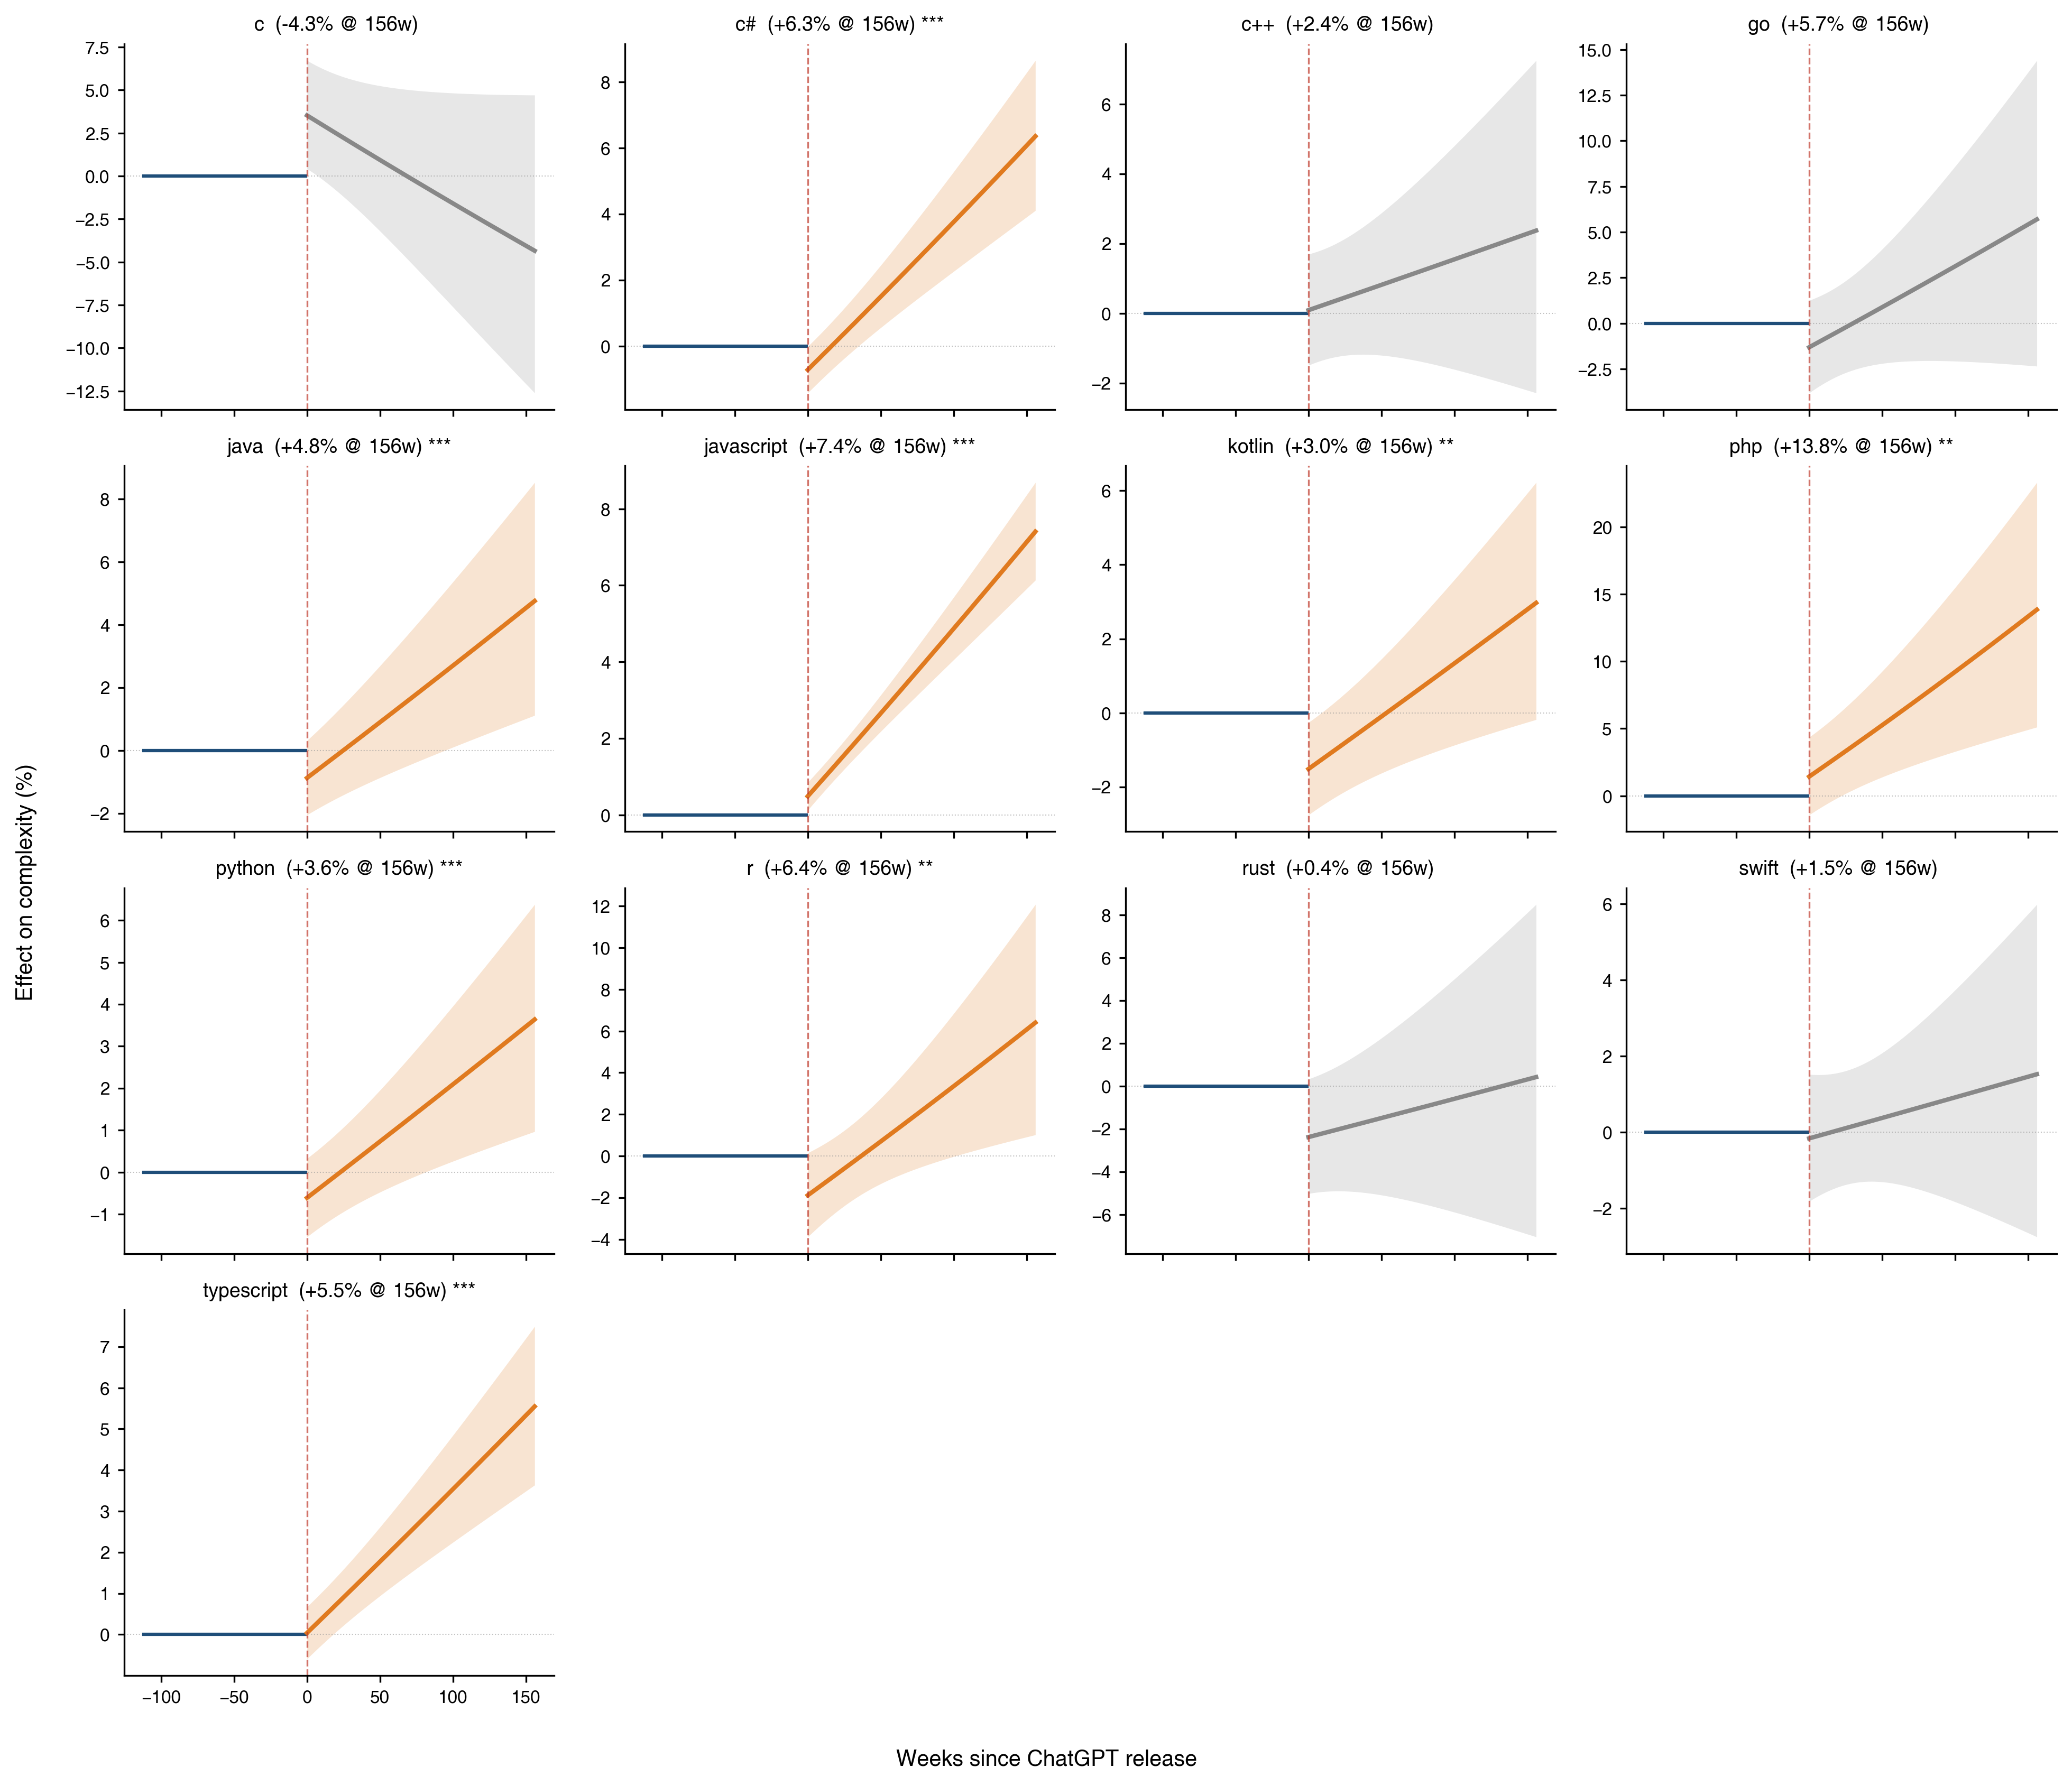


요약 통계
분석 언어: 13  (제외: ['fortran', 'lua', 'objective-c', 'ruby', 'scala', 'solidity'])

Slope change:
  유의 양수: 8
  유의 음수: 0
  비유의:    5

누적 효과 (156주):
  중앙값: +4.76%
  범위:   [-4.34%, +13.84%]
  Pooled: +4.73%


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.formula.api as smf
from matplotlib.lines import Line2D

# ═══════════════════════════════════════════
# 폰트 / 팔레트
# ═══════════════════════════════════════════
# mpl.rcParams['font.family'] = 'DejaVu Sans'
# mpl.rcParams['mathtext.fontset'] = 'cm'
# mpl.rcParams['axes.unicode_minus'] = False

PALETTE = {
    'primary': '#1f4e79', 'accent': '#E07A1F',
    'event':   '#C0392B', 'neutral': '#888888', 'point': '#BBBBBB',
}

# ═══════════════════════════════════════════
# 0. 설정
# ═══════════════════════════════════════════
CHATGPT_DATE = pd.Timestamp('2022-11-30')
TARGET       = 'log_cc_mean'
BIN_SIZE     = 4
MIN_BIN, MAX_BIN = -28, +39
MIN_WEEK = MIN_BIN * BIN_SIZE   # -112
MAX_WEEK = MAX_BIN * BIN_SIZE   # +156
HAC_LAGS = 8
FINAL_T  = MAX_WEEK

# ★ 언어 포함 기준 (pre/post 각각 최소 주 수)
MIN_PRE  = 50
MIN_POST = 50

def beta_to_pct(b):
    return (np.exp(b) - 1) * 100

# ═══════════════════════════════════════════
# 1. 데이터 준비
# ═══════════════════════════════════════════
df = tot_viz_df.copy()
df['creationdate'] = pd.to_datetime(df['creationdate'], format='mixed')
df = df[df['cyclomatic_complexity'] > 0].dropna(subset=['nloc']).copy()
df['log_cc'] = np.log1p(df['cyclomatic_complexity'])
df['week']   = df['creationdate'].dt.to_period('W').dt.start_time

valid = df['language'].value_counts()[lambda s: s >= 1000].index
df = df[df['language'].isin(valid)].copy()

weekly = df.groupby(['language', 'week']).agg(
    log_cc_mean = ('log_cc', 'mean'),
    log_cc_std  = ('log_cc', 'std'),
    n_func      = ('cyclomatic_complexity', 'count'),
).reset_index()

weekly = weekly[weekly['n_func'] >= 30].copy()
weekly['weeks_since'] = ((weekly['week'] - CHATGPT_DATE).dt.days / 7).round().astype(int)
weekly = weekly[(weekly['weeks_since'] >= MIN_WEEK) &
                (weekly['weeks_since'] <= MAX_WEEK)].copy()

weekly['t']      = weekly['weeks_since']
weekly['post']   = (weekly['weeks_since'] >= 0).astype(int)
weekly['post_t'] = weekly['post'] * weekly['weeks_since']
weekly = weekly.sort_values(['language', 't']).reset_index(drop=True)

# ★ pre/post 데이터 충분한 언어만 선별
cov = weekly.groupby('language').agg(
    n_pre  = ('t', lambda s: (s < 0).sum()),
    n_post = ('t', lambda s: (s >= 0).sum()),
).reset_index()
keep_langs = cov[(cov['n_pre'] >= MIN_PRE) &
                 (cov['n_post'] >= MIN_POST)]['language'].tolist()

dropped = sorted(set(weekly['language'].unique()) - set(keep_langs))
weekly = weekly[weekly['language'].isin(keep_langs)].copy()

print(f"포함 언어 ({len(keep_langs)}): {sorted(keep_langs)}")
print(f"제외 언어 ({len(dropped)}): {dropped}")
print(f"기준: pre>={MIN_PRE}, post>={MIN_POST}주")
print(f"분석 데이터: {len(weekly):,}개 행")

# ═══════════════════════════════════════════
# 2. Pooled ITS
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("Pooled ITS (HAC SE, 언어 고정효과)")
print("="*60)

formula_pool = f'{TARGET} ~ t + post + post_t + C(language)'
m_pool = smf.wls(
    formula_pool, data=weekly, weights=weekly['n_func']
).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_LAGS})

pool_level_pct = beta_to_pct(m_pool.params['post'])
pool_slope_pct = beta_to_pct(m_pool.params['post_t'])
pool_final_log = m_pool.params['post'] + m_pool.params['post_t'] * FINAL_T
pool_final_pct = beta_to_pct(pool_final_log)

print(f"  Level change: {pool_level_pct:+.3f}%")
print(f"  Slope change: {pool_slope_pct:+.4f}%/week")
print(f"  최종 누적 ({FINAL_T}주): {pool_final_pct:+.2f}%")

# ═══════════════════════════════════════════
# 3. 언어별 ITS (모형 저장 → 재사용)
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("언어별 ITS")
print("="*60)

formula_lang = f'{TARGET} ~ t + post + post_t'
its_lang_results = []
lang_models = {}

for lang in sorted(weekly['language'].unique()):
    sub = weekly[weekly['language'] == lang].sort_values('t').copy()
    try:
        m = smf.wls(formula_lang, data=sub, weights=sub['n_func']).fit(
            cov_type='HAC', cov_kwds={'maxlags': HAC_LAGS}
        )
    except Exception as e:
        print(f"[SKIP] {lang}: {e}")
        continue
    if m.bse.isna().any():
        print(f"[SKIP] {lang}: NaN SE")
        continue

    lang_models[lang] = m
    final_log = m.params['post'] + m.params['post_t'] * FINAL_T

    its_lang_results.append({
        'language':         lang,
        'n_func':           df[df['language'] == lang].shape[0],
        'n_obs':            len(sub),
        'pre_trend':        m.params['t'],
        'pre_trend_p':      m.pvalues['t'],
        'level_change':     m.params['post'],
        'level_change_p':   m.pvalues['post'],
        'level_change_pct': beta_to_pct(m.params['post']),
        'slope_change':     m.params['post_t'],
        'slope_change_se':  m.bse['post_t'],
        'slope_change_p':   m.pvalues['post_t'],
        'slope_change_pct': beta_to_pct(m.params['post_t']),
        'final_effect':     final_log,
        'final_effect_pct': beta_to_pct(final_log),
        'r_squared':        m.rsquared,
    })

its_lang_df = pd.DataFrame(its_lang_results)

print(f"\n언어별 ITS 결과 (n={len(its_lang_df)}):")
print(its_lang_df[['language', 'n_func',
                   'level_change_pct', 'level_change_p',
                   'slope_change_pct', 'slope_change_p',
                   'final_effect_pct']]
      .sort_values('final_effect_pct', ascending=False)
      .to_string(index=False))

# ═══════════════════════════════════════════
# 4. Forest plot
# ═══════════════════════════════════════════
def categorize(row):
    if row['slope_change_p'] >= 0.05:
        return PALETTE['neutral']
    return PALETTE['accent'] if row['slope_change'] > 0 else PALETTE['primary']

its_lang_df['color_final'] = its_lang_df.apply(categorize, axis=1)
its_lang_df['alpha'] = its_lang_df['color_final'].apply(
    lambda c: 0.55 if c == PALETTE['neutral'] else 1.0)

sorted_eff = its_lang_df.sort_values('final_effect_pct').reset_index(drop=True)

fig_h = max(3.0, 0.34 * len(sorted_eff))
fig, ax = plt.subplots(figsize=(6.5, fig_h), dpi=300)

ax.axvline(0, color='#333', lw=0.6, zorder=1)
ax.axvline(pool_final_pct, color=PALETTE['event'], lw=0.9, ls='--', zorder=1)

for i, row in sorted_eff.iterrows():
    ax.plot([0, row['final_effect_pct']], [i, i],
            color=row['color_final'], lw=1.0, alpha=row['alpha']*0.7, zorder=2)
    ax.scatter(row['final_effect_pct'], i, s=46,
               facecolor=row['color_final'], edgecolor='white',
               linewidth=0.7, alpha=row['alpha'], zorder=3)

ax.set_yticks(np.arange(len(sorted_eff)))
ax.set_yticklabels([f"{r['language']}  (n={r['n_func']:,})"
                    for _, r in sorted_eff.iterrows()], fontsize=8.5)
ax.set_xlabel(f'Cumulative ITS effect at week {FINAL_T} (%)')
ax.set_title('Language-specific ITS: cumulative effect',
             fontsize=10, loc='left', pad=8, color='#222')

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['accent'],
           markersize=7, markeredgecolor='white', markeredgewidth=1,
           label='Significant increase (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['primary'],
           markersize=7, markeredgecolor='white', markeredgewidth=1,
           label='Significant decrease (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['neutral'],
           markersize=7, markeredgecolor='white', markeredgewidth=1,
           alpha=0.55, label='Not significant'),
    Line2D([0],[0], color=PALETTE['event'], lw=0.9, ls='--',
           label=f'Pooled: {pool_final_pct:+.2f}%'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, frameon=False)

for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_position(('outward', 3))
ax.tick_params(axis='y', length=0)

plt.tight_layout()
# plt.savefig('its_language_forest.png', dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig('its_language_forest.pdf',           bbox_inches='tight', facecolor='white')
plt.show()

# ═══════════════════════════════════════════
# 5. 언어별 ITS 그리드 (저장 모형 재사용)
# ═══════════════════════════════════════════
languages = sorted(its_lang_df['language'].unique())
n_lang = len(languages)
n_cols = 4
n_rows = (n_lang + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 2.8*n_rows),
                         sharex=True, sharey=False, dpi=300)
axes_flat = axes.flatten()

t_grid = np.arange(MIN_WEEK, MAX_WEEK + 1)
pre_mask, post_mask = t_grid < 0, t_grid >= 0

for ax, lang in zip(axes_flat, languages):
    m = lang_models[lang]
    β_p, β_pt = m.params['post'], m.params['post_t']
    cov_m = m.cov_params()
    v_p    = cov_m.loc['post', 'post']
    v_pt   = cov_m.loc['post_t', 'post_t']
    c_p_pt = cov_m.loc['post', 'post_t']

    eff = np.where(t_grid >= 0, β_p + β_pt * t_grid, 0.0)
    var = np.where(t_grid >= 0,
                   v_p + (t_grid**2)*v_pt + 2*t_grid*c_p_pt, 0.0)
    se  = np.sqrt(np.maximum(var, 0))
    eff_pct = beta_to_pct(eff)
    ci_low  = beta_to_pct(eff - 1.96*se)
    ci_high = beta_to_pct(eff + 1.96*se)

    color = its_lang_df.set_index('language').loc[lang, 'color_final']

    ax.axhline(0, color='#999', lw=0.5, ls=':', alpha=0.6)
    ax.fill_between(t_grid[post_mask], ci_low[post_mask], ci_high[post_mask],
                    alpha=0.2, color=color, lw=0)
    ax.plot(t_grid[pre_mask],  eff_pct[pre_mask],  color=PALETTE['primary'], lw=1.5)
    ax.plot(t_grid[post_mask], eff_pct[post_mask], color=color, lw=2)
    ax.axvline(0, color=PALETTE['event'], ls='--', alpha=0.7, lw=0.8)

    final_pct = its_lang_df.set_index('language').loc[lang, 'final_effect_pct']
    slope_p   = its_lang_df.set_index('language').loc[lang, 'slope_change_p']
    sig = '***' if slope_p<0.001 else '**' if slope_p<0.01 else '*' if slope_p<0.05 else ''
    ax.set_title(f'{lang}  ({final_pct:+.1f}% @ {FINAL_T}w) {sig}', fontsize=9)
    ax.tick_params(labelsize=8)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)

for ax in axes_flat[len(languages):]:
    ax.axis('off')

fig.supxlabel('Weeks since ChatGPT release', fontsize=10, y=0.0)
fig.supylabel('Effect on complexity (%)',    fontsize=10, x=0.0)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════
# 6. 요약
# ═══════════════════════════════════════════
print("\n" + "="*60)
print("요약 통계")
print("="*60)
print(f"분석 언어: {len(its_lang_df)}  (제외: {dropped})")
print(f"\nSlope change:")
print(f"  유의 양수: {((its_lang_df['slope_change']>0)&(its_lang_df['slope_change_p']<0.05)).sum()}")
print(f"  유의 음수: {((its_lang_df['slope_change']<0)&(its_lang_df['slope_change_p']<0.05)).sum()}")
print(f"  비유의:    {(its_lang_df['slope_change_p']>=0.05).sum()}")
print(f"\n누적 효과 ({FINAL_T}주):")
print(f"  중앙값: {its_lang_df['final_effect_pct'].median():+.2f}%")
print(f"  범위:   [{its_lang_df['final_effect_pct'].min():+.2f}%, {its_lang_df['final_effect_pct'].max():+.2f}%]")
print(f"  Pooled: {pool_final_pct:+.2f}%")

In [10]:
panel = pd.DataFrame()
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    print(f'[Start....] Aggreagate data for {lang} language')
    tmp = load_df(f'/mnt/hdd/mghan/so_data_availability/result/tag/run_id_{100+idx}/data', ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
    tmp['language'] = lang
    panel = pd.concat([panel, tmp], axis = 0)
    

[Start....] Aggreagate data for python language


100%|██████████| 153/153 [00:06<00:00, 22.11it/s]


[Start....] Aggreagate data for javascript language


100%|██████████| 108/108 [00:06<00:00, 17.06it/s]


[Start....] Aggreagate data for java language


...

100%|██████████| 1/1 [00:00<00:00, 71.37it/s]


[Start....] Aggreagate data for f# language


100%|██████████| 1/1 [00:00<00:00, 118.64it/s]


[Start....] Aggreagate data for solidity language


100%|██████████| 2/2 [00:00<00:00, 59.59it/s]


In [11]:
panel['rel_week'] = (pd.to_datetime(panel['cdate']) - datetime(2022, 11, 30)).dt.days //7

In [12]:
panel

,cdate,id,tag,cnt,tot_cnt,pct,language,rel_week
0,2021-06-08,67890341,selenium,1,3,0.333333,python,-78
1,2021-06-08,67890341,xpath,1,3,0.333333,python,-78
2,2021-06-08,67890341,webautomation,1,3,0.333333,python,-78
3,2021-06-08,67890350,dictionary,1,1,1.000000,python,-78
4,2021-06-08,67890401,matplotlib,1,1,1.000000,python,-78
...,...,...,...,...,...,...,...,...
12132,2025-10-24,79798683,nft,1,4,0.250000,solidity,151
12133,2025-10-24,79798683,ether,1,4,0.250000,solidity,151
12134,2025-11-04,79808575,node.js,1,3,0.333333,solidity,152
12135,2025-11-04,79808575,blockchain,1,3,0.333333,solidity,152


In [13]:
panel = panel[panel['rel_week']<0].groupby(['language'])['pct'].sum().reset_index().rename(columns = {'pct' : 'post_count'})

In [14]:
panel['log_post_count'] = np.log(panel['post_count'])

In [15]:
its_lang_df = pd.merge(its_lang_df, panel, on = 'language')

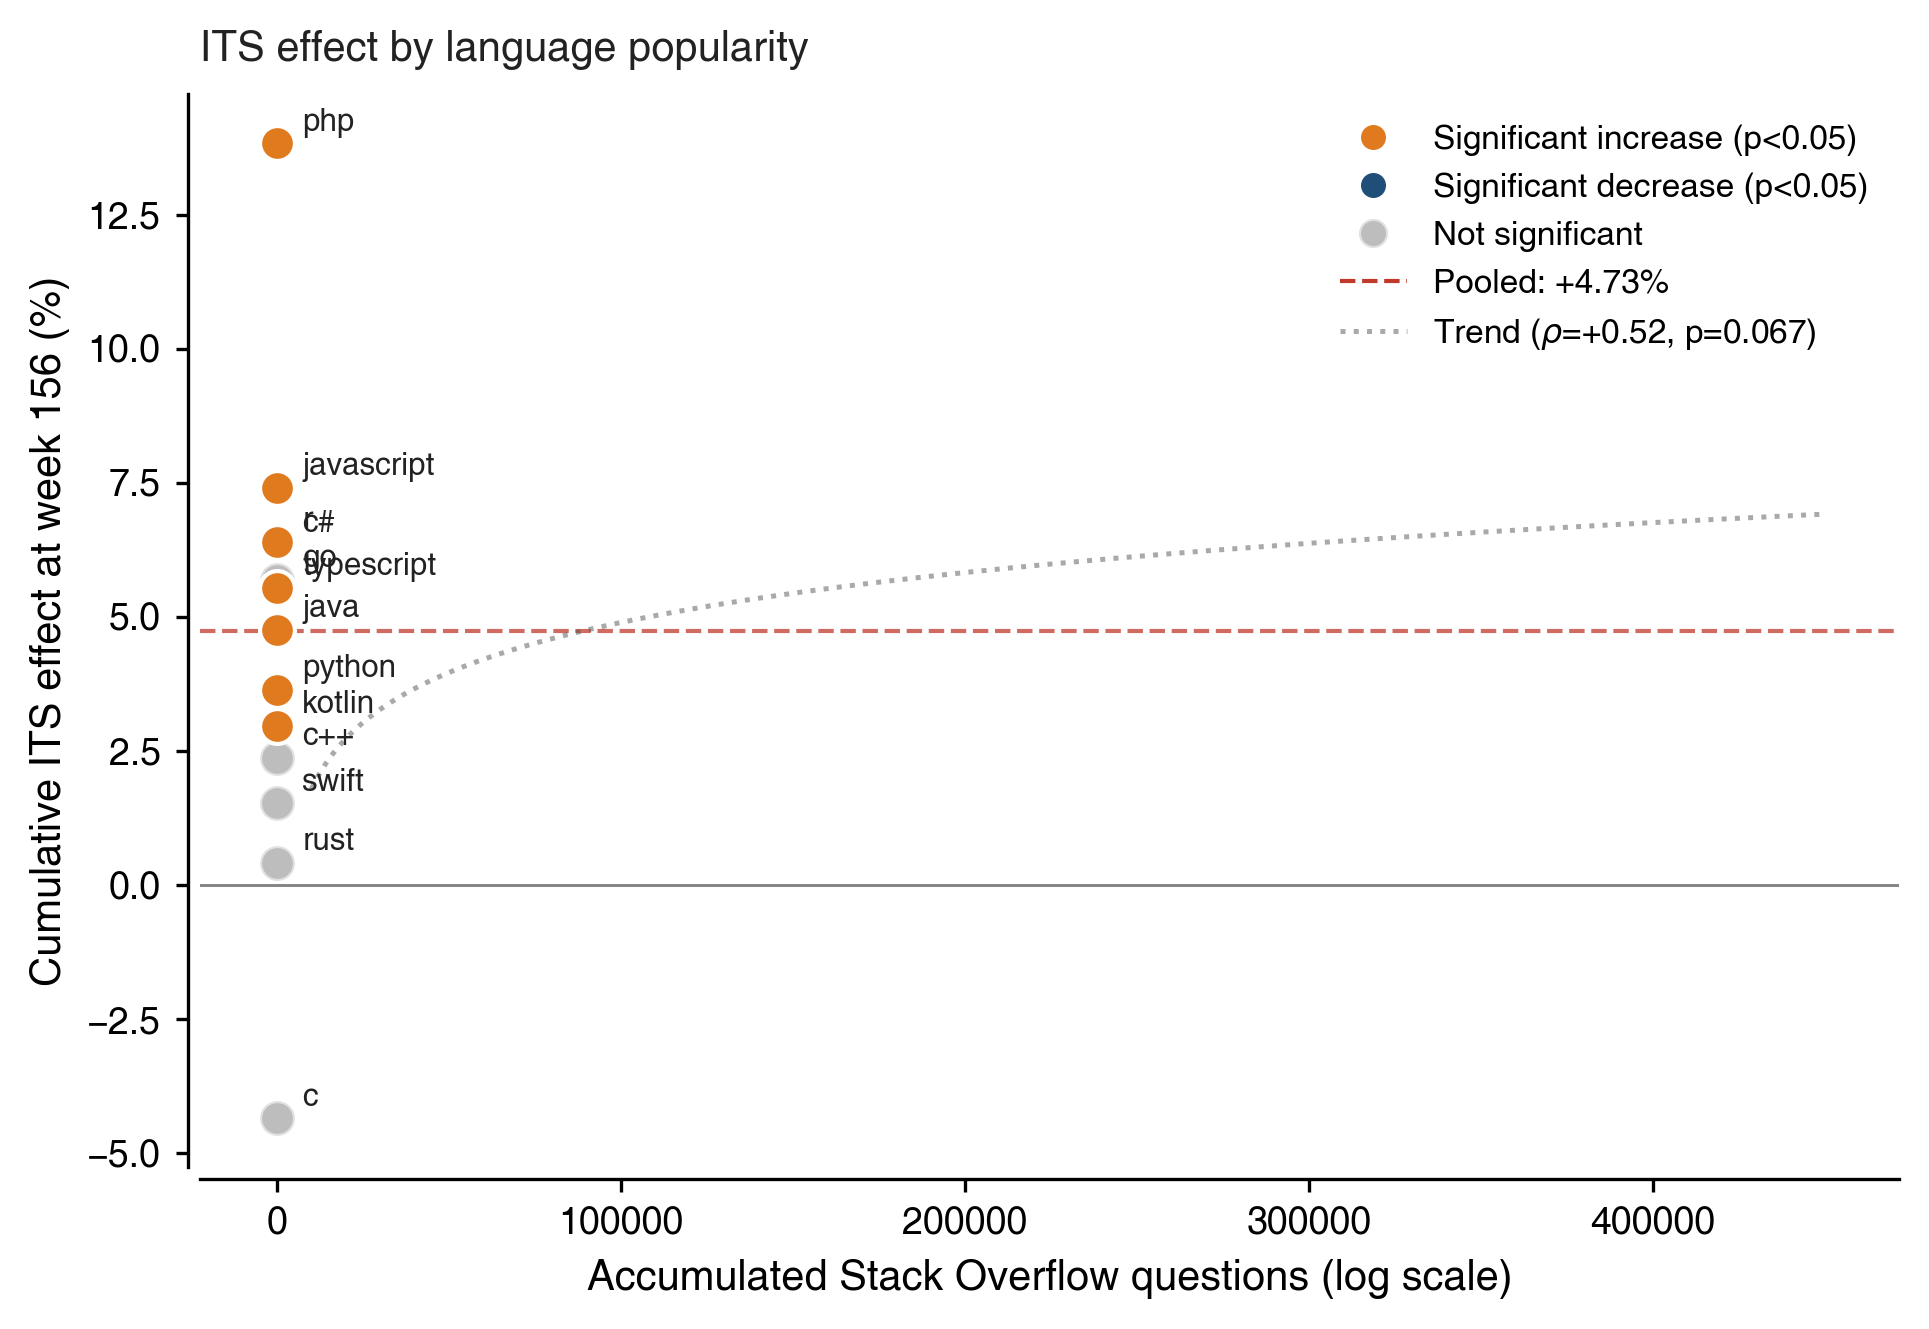

Spearman ρ = +0.522, p = 0.0673
분석 언어 수: 13


In [16]:
# ═══════════════════════════════════════════
# 0. 누적 질문량 데이터 머지
# ═══════════════════════════════════════════
# 본인의 질문량 데이터를 language → accumulated_questions 형태로 준비
# 예시: dict 또는 DataFrame
#   q_data = {'python': 2_100_000, 'javascript': 2_400_000, ...}
#   또는 questions_df[['language', 'accumulated_questions']]

# # dict인 경우
# its_lang_df['n_questions'] = its_lang_df['language'].map(q_data)

# # DataFrame인 경우
# # its_lang_df = its_lang_df.merge(
# #     questions_df[['language', 'accumulated_questions']],
# #     on='language', how='left'
# # ).rename(columns={'accumulated_questions': 'n_questions'})

# # 질문량 없는 언어 확인
# missing = its_lang_df[its_lang_df['n_questions'].isna()]['language'].tolist()
# if missing:
#     print(f"질문량 데이터 없는 언어: {missing}")
# its_lang_df = its_lang_df.dropna(subset=['n_questions']).copy()

# ═══════════════════════════════════════════
# 4. Scatter — 누적 질문량 vs ITS 누적 효과
# ═══════════════════════════════════════════
from scipy.stats import spearmanr
from scipy.stats import linregress

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=300)

# 기준선
ax.axhline(0, color='#333', lw=0.7, alpha=0.6, zorder=1)
ax.axhline(pool_final_pct, color=PALETTE['event'], lw=1.0, ls='--',
           alpha=0.75, zorder=1)

# Scatter
for _, row in its_lang_df.iterrows():
    ax.scatter(row['log_post_count'], row['final_effect_pct'],
               s=70, facecolor=row['color_final'], edgecolor='white',
               linewidth=1.0, alpha=row['alpha'], zorder=3)

# log 스케일
# ax.set_xscale('log')

# 추세선 + Spearman (log 질문량 기준)
log_q = np.log10(its_lang_df['post_count'])
rho, p_corr = spearmanr(its_lang_df['log_post_count'], its_lang_df['final_effect_pct'])
res = linregress(log_q, its_lang_df['final_effect_pct'])
x_line = np.logspace(log_q.min(), log_q.max(), 100)
y_line = res.slope * np.log10(x_line) + res.intercept
ax.plot(x_line, y_line, color='#555', lw=1.2, alpha=0.5, ls=':', zorder=2)

# 라벨 (adjustText 권장 — 겹침 방지)
try:
    from adjustText import adjust_text
    texts = [ax.text(row['log_post_count'], row['final_effect_pct'], row['language'],
                     fontsize=7.5, color='#222')
             for _, row in its_lang_df.iterrows()]
    adjust_text(texts, ax=ax, expand=(1.2, 1.4),
                arrowprops=dict(arrowstyle='-', color='#888', lw=0.4))
except ImportError:
    for _, row in its_lang_df.iterrows():
        ax.annotate(row['language'],
                    xy=(row['log_post_count'], row['final_effect_pct']),
                    xytext=(6, 3), textcoords='offset points',
                    fontsize=7.5, color='#222')

# 스타일
ax.set_xlabel('Accumulated Stack Overflow questions (log scale)', fontsize=10)
ax.set_ylabel(f'Cumulative ITS effect at week {FINAL_T} (%)', fontsize=10)
ax.set_title('ITS effect by language popularity',
             fontsize=10, loc='left', pad=8, color='#222')

for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.spines['bottom'].set_position(('outward', 3))
ax.spines['left'].set_position(('outward', 3))
ax.grid(False)

# 범례
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['accent'],
           markersize=7, markeredgecolor='white', markeredgewidth=1,
           label='Significant increase (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['primary'],
           markersize=7, markeredgecolor='white', markeredgewidth=1,
           label='Significant decrease (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['neutral'],
           markersize=7, markeredgecolor='white', markeredgewidth=1,
           alpha=0.55, label='Not significant'),
    Line2D([0],[0], color=PALETTE['event'], lw=1.0, ls='--',
           label=f'Pooled: {pool_final_pct:+.2f}%'),
    Line2D([0],[0], color='#555', lw=1.2, ls=':', alpha=0.5,
           label=f'Trend ($\\rho$={rho:+.2f}, p={p_corr:.3f})'),
]
ax.legend(handles=legend_elements, loc='best', fontsize=8, frameon=False)

plt.tight_layout()
# plt.savefig('its_questions_scatter.png', dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig('its_questions_scatter.pdf',           bbox_inches='tight', facecolor='white')
plt.show()

print(f"Spearman ρ = {rho:+.3f}, p = {p_corr:.4f}")
print(f"분석 언어 수: {len(its_lang_df)}")

In [17]:
from scipy.stats import linregress, spearmanr

res = linregress(log_q, its_lang_df['final_effect_pct'])
rho, p_sp = spearmanr(its_lang_df['log_post_count'], its_lang_df['final_effect_pct'])

print(f"OLS:      slope={res.slope:+.3f}, R²={res.rvalue**2:.3f}, p={res.pvalue:.4f}")
print(f"Spearman: rho={rho:+.3f}, p={p_sp:.4f}")

OLS:      slope=+3.093, R²=0.121, p=0.2442
Spearman: rho=+0.522, p=0.0673


In [18]:
from scipy.stats import linregress

log_q = its_lang_df['log_post_count']
res = linregress(log_q, its_lang_df['final_effect_pct'])

r2    = res.rvalue ** 2          # = 피어슨 r²
p_ols = res.pvalue
p_str = '$p$ < 0.001' if p_ols < 0.001 else f'$p$ = {p_ols:.3f}'

# 범례
label=f'OLS trend ($R^2$={r2:.2f}, {p_str})'
print(label)



OLS trend ($R^2$=0.12, $p$ = 0.244)


In [19]:
from scipy.stats import linregress, pearsonr, spearmanr

log_q = its_lang_df['log_post_count']
y = its_lang_df['final_effect_pct']

res = linregress(log_q, y)
r_p, p_p   = pearsonr(log_q, y)       # 피어슨 (log 질문량 기준)
rho, p_sp  = spearmanr(its_lang_df['log_post_count'], y)  # 스피어만

print(f"OLS:      slope={res.slope:+.3f}, R²={res.rvalue**2:.3f}, p={res.pvalue:.4f}")
print(f"Pearson:  r={r_p:+.3f}, p={p_p:.4f}")
print(f"Spearman: rho={rho:+.3f}, p={p_sp:.4f}")

OLS:      slope=+1.343, R²=0.121, p=0.2442
Pearson:  r=+0.348, p=0.2442
Spearman: rho=+0.522, p=0.0673


TTLibError: not enough 'glyf' table data

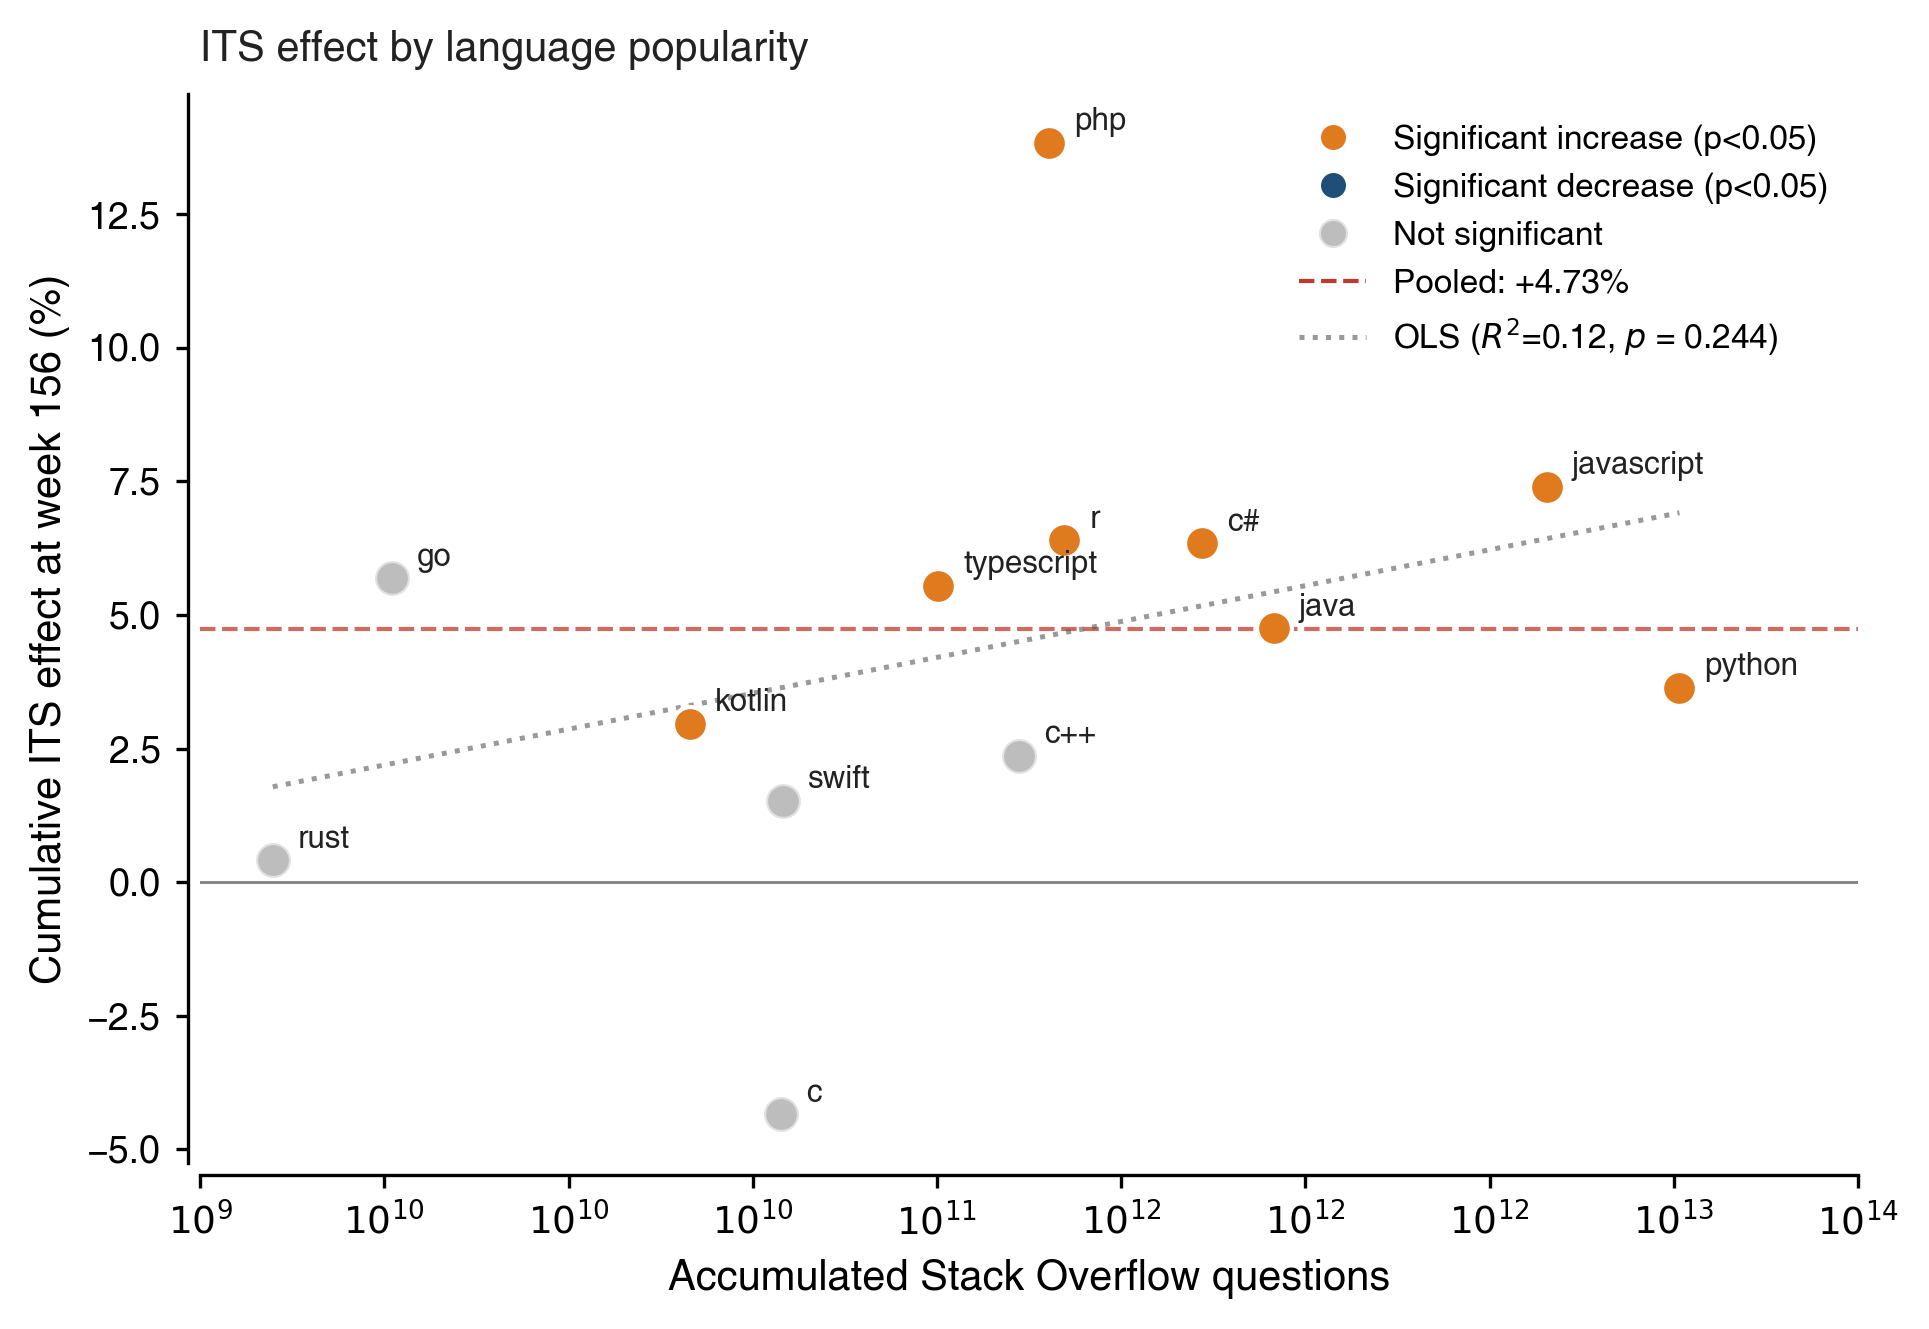

In [ ]:
from scipy.stats import linregress, spearmanr

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=300)

# 기준선
ax.axhline(0, color='#333', lw=0.7, alpha=0.6, zorder=1)
ax.axhline(pool_final_pct, color=PALETTE['event'], lw=1.0, ls='--',
           alpha=0.75, zorder=1)

# Scatter — x는 log_post_count (이미 log값)
for _, row in its_lang_df.iterrows():
    ax.scatter(row['log_post_count'], row['final_effect_pct'],
               s=70, facecolor=row['color_final'], edgecolor='white',
               linewidth=1.0, alpha=row['alpha'], zorder=3)

# ★ set_xscale('log') 제거! (이미 log값이라 일반 축)

# OLS 추세선 — x도 log_post_count로 일관
x = its_lang_df['log_post_count'].values
y = its_lang_df['final_effect_pct'].values
res = linregress(x, y)

x_line = np.linspace(x.min(), x.max(), 100)   # ★ logspace 아님, 일반 linspace
y_line = res.slope * x_line + res.intercept
ax.plot(x_line, y_line, color='#555', lw=1.2, alpha=0.6, ls=':', zorder=2)

r2 = res.rvalue ** 2
p_str = '$p$ < 0.001' if res.pvalue < 0.001 else f'$p$ = {res.pvalue:.3f}'

# 라벨
try:
    from adjustText import adjust_text
    texts = [ax.text(row['log_post_count'], row['final_effect_pct'], row['language'],
                     fontsize=7.5, color='#222')
             for _, row in its_lang_df.iterrows()]
    adjust_text(texts, ax=ax, expand=(1.2, 1.4),
                arrowprops=dict(arrowstyle='-', color='#888', lw=0.4))
except ImportError:
    for _, row in its_lang_df.iterrows():
        ax.annotate(row['language'],
                    xy=(row['log_post_count'], row['final_effect_pct']),
                    xytext=(6, 3), textcoords='offset points',
                    fontsize=7.5, color='#222')

# ★ x축 tick을 실제 규모로 (원하면)
ticks = ax.get_xticks()
ax.set_xticks(ticks)
ax.set_xticklabels([f'$10^{{{t:.0f}}}$' for t in ticks])

ax.set_xlabel('Accumulated Stack Overflow questions', fontsize=10)
ax.set_ylabel(f'Cumulative ITS effect at week {FINAL_T} (%)', fontsize=10)
ax.set_title('ITS effect by language popularity',
             fontsize=10, loc='left', pad=8, color='#222')

for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.spines['bottom'].set_position(('outward', 3))
ax.spines['left'].set_position(('outward', 3))
ax.grid(False)

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['accent'],
           markersize=7, markeredgecolor='white', markeredgewidth=1,
           label='Significant increase (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['primary'],
           markersize=7, markeredgecolor='white', markeredgewidth=1,
           label='Significant decrease (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['neutral'],
           markersize=7, markeredgecolor='white', markeredgewidth=1,
           alpha=0.55, label='Not significant'),
    Line2D([0],[0], color=PALETTE['event'], lw=1.0, ls='--',
           label=f'Pooled: {pool_final_pct:+.2f}%'),
    Line2D([0],[0], color='#555', lw=1.2, ls=':', alpha=0.6,
           label=f'OLS ($R^2$={r2:.2f}, {p_str})'),
]
ax.legend(handles=legend_elements, loc='best', fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

# 보고용: 셋 다 출력
r_p, p_p  = (res.rvalue, res.pvalue)
rho, p_sp = spearmanr(its_lang_df['log_post_count'], its_lang_df['final_effect_pct'])
print(f"OLS/Pearson: r={res.rvalue:+.3f}, R²={r2:.3f}, p={res.pvalue:.4f}")
print(f"Spearman:    rho={rho:+.3f}, p={p_sp:.4f}")

In [32]:
its_lang_df['post_count'] = its_lang_df['post_count'].astype(int)

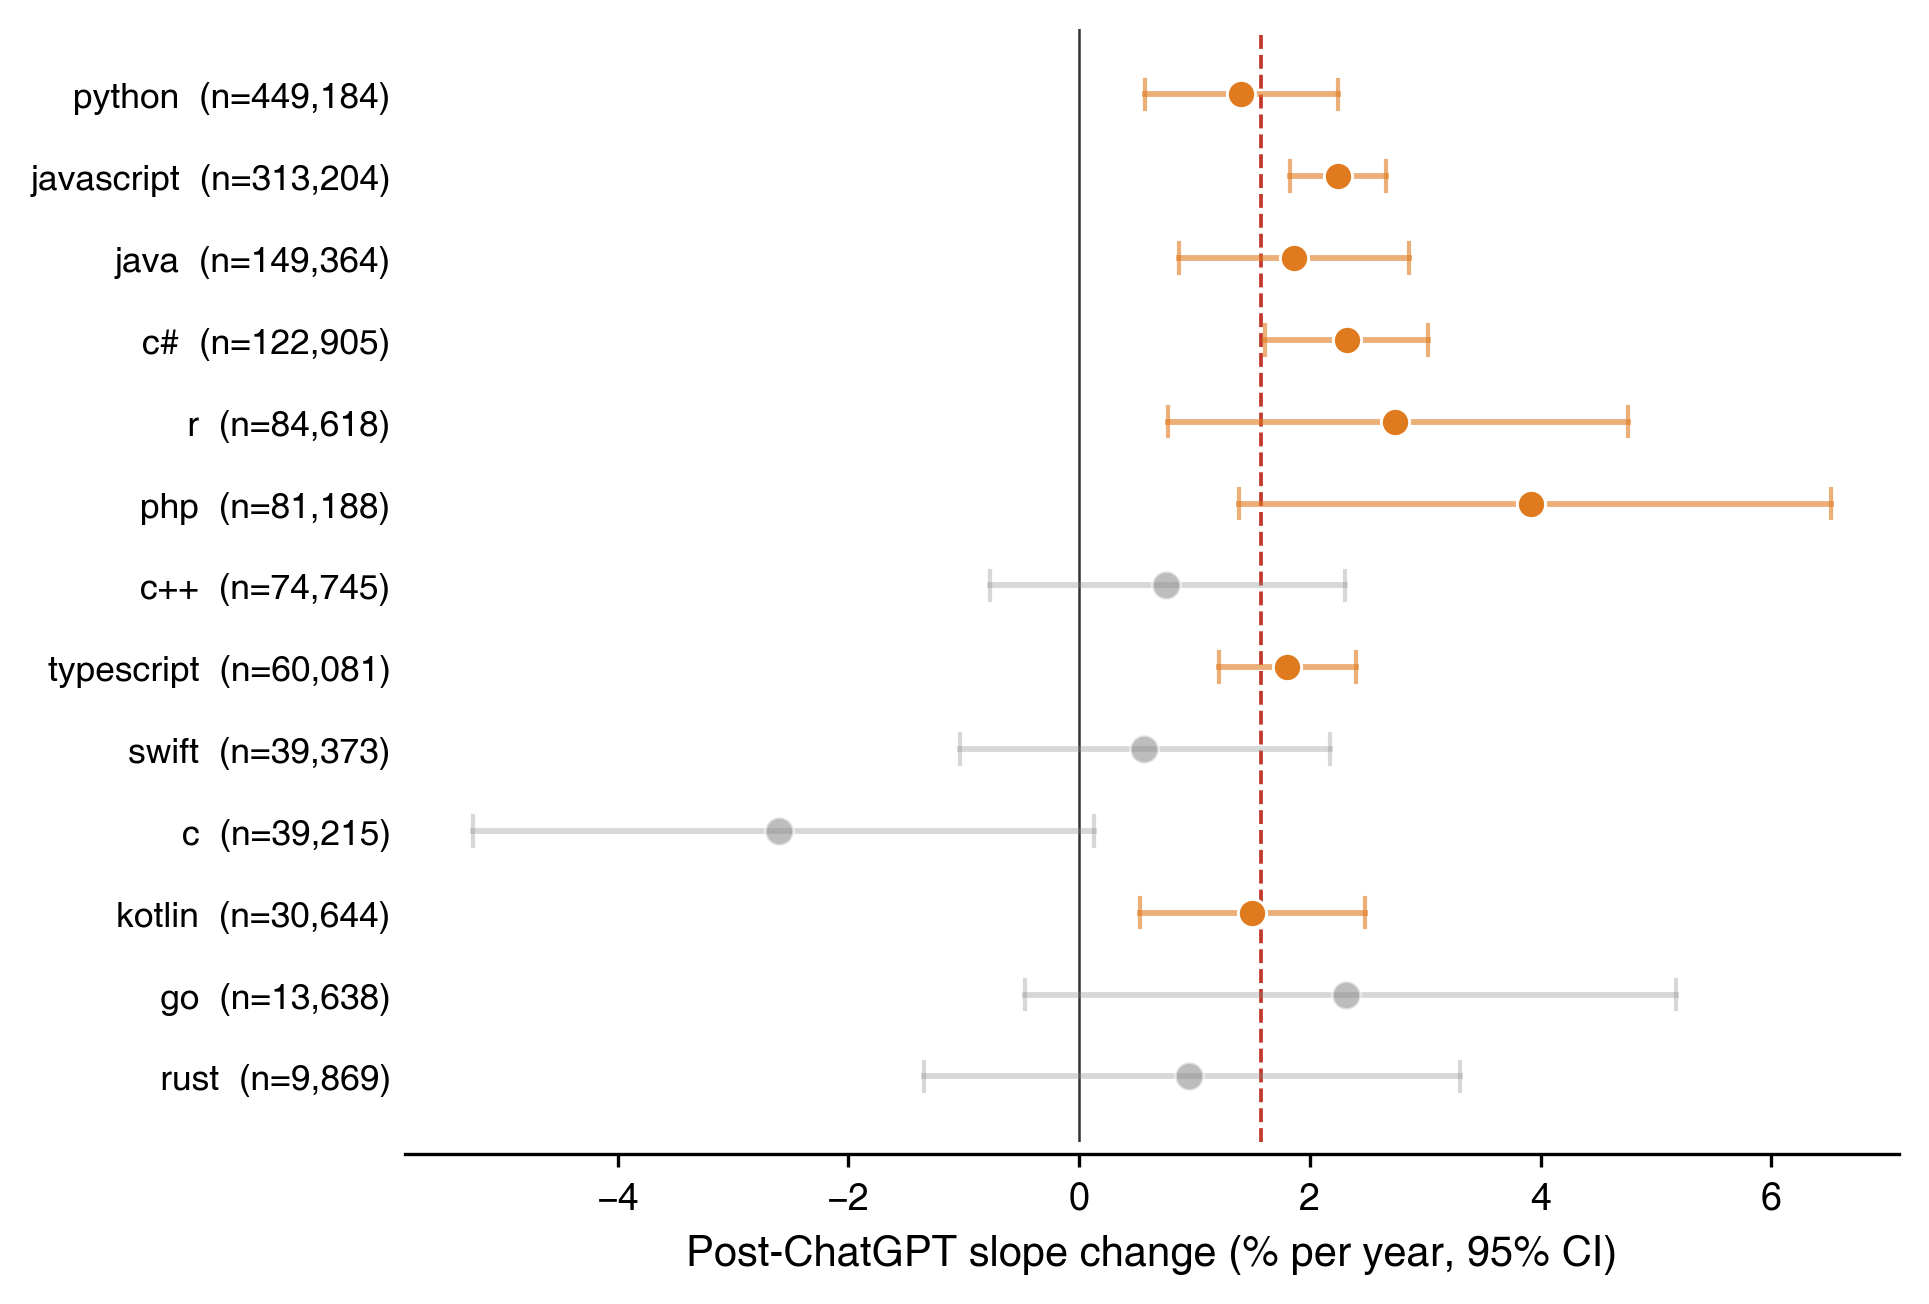

In [ ]:
from matplotlib.lines import Line2D

# ── slope change 연 단위 + CI (delta method, post_t의 SE 직접 사용)
its_lang_df['slope_yr_pct']    = (np.exp(its_lang_df['slope_change'] * 52) - 1) * 100
its_lang_df['slope_yr_lo_pct'] = (np.exp((its_lang_df['slope_change'] - 1.96*its_lang_df['slope_change_se']) * 52) - 1) * 100
its_lang_df['slope_yr_hi_pct'] = (np.exp((its_lang_df['slope_change'] + 1.96*its_lang_df['slope_change_se']) * 52) - 1) * 100

# Pooled slope change
pool_slope_yr = (np.exp(m_pool.params['post_t'] * 52) - 1) * 100

# 색: slope change 유의성 기준 (CI가 0 포함 여부와 일치)
def categorize(row):
    if row['slope_change_p'] >= 0.05:
        return PALETTE['neutral']
    return PALETTE['accent'] if row['slope_change'] > 0 else PALETTE['primary']

its_lang_df['color_slope'] = its_lang_df.apply(categorize, axis=1)
its_lang_df['alpha'] = its_lang_df['color_slope'].apply(
    lambda c: 0.55 if c == PALETTE['neutral'] else 1.0)

sorted_s = its_lang_df.sort_values('log_post_count', ascending=True).reset_index(drop=True)

fig_h = max(3.0, 0.34 * len(sorted_s))
fig, ax = plt.subplots(figsize=(6.5, fig_h), dpi=300)

ax.axvline(0, color='#333', lw=0.6, zorder=1)
# ax.axvline(pool_slope_yr, color=PALETTE['event'], lw=0.9, ls='--', zorder=1)

for i, row in sorted_s.iterrows():
    # 95% CI 막대
    ax.plot([row['slope_yr_lo_pct'], row['slope_yr_hi_pct']], [i, i],
            color=row['color_slope'], lw=1.4, alpha=row['alpha']*0.6, zorder=2)
    for xe in [row['slope_yr_lo_pct'], row['slope_yr_hi_pct']]:
        ax.plot([xe, xe], [i-0.18, i+0.18],
                color=row['color_slope'], lw=1.0, alpha=row['alpha']*0.6, zorder=2)
    # 점추정
    ax.scatter(row['slope_yr_pct'], i, s=46,
               facecolor=row['color_slope'], edgecolor='white',
               linewidth=0.7, alpha=row['alpha'], zorder=3)

ax.set_yticks(np.arange(len(sorted_s)))
ax.set_yticklabels([f"{r['language']}  (n={r['post_count']:,})"
                    for _, r in sorted_s.iterrows()], fontsize=8.5)
ax.set_xlabel('Post-ChatGPT slope change (% per year, 95% CI)')
# ax.set_title('Language-specific ITS: trend change',
#              fontsize=10, loc='left', pad=8, color='#222')

# legend_elements = [
#     Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['accent'],
#            markersize=7, markeredgecolor='white', markeredgewidth=1,
#            label='Significant steepening (p<0.05)'),
#     Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['primary'],
#            markersize=7, markeredgecolor='white', markeredgewidth=1,
#            label='Significant flattening (p<0.05)'),
#     Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['neutral'],
#            markersize=7, markeredgecolor='white', markeredgewidth=1,
#            alpha=0.55, label='Not significant'),
#     Line2D([0],[0], color=PALETTE['event'], lw=0.9, ls='--',
#            label=f'Pooled: {pool_slope_yr:+.2f}%/yr'),
# ]
# # ax.legend(handles=legend_elements, loc='lower right', fontsize=8, frameon=False)
# ax.legend(handles=legend_elements,
#           loc='upper left',              # 범례 박스의 어느 모서리를 기준점에 맞출지
#           bbox_to_anchor=(1.02, 1.0),    # axes 오른쪽 바깥 (1.0 = 오른쪽 끝)
#           fontsize=8, frameon=False)

for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_position(('outward', 3))
ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import linregress, spearmanr


fig, ax = plt.subplots(figsize=(figure_setting.FIG_SIZE['x']+2, figure_setting.FIG_SIZE['y']+1), dpi=300)

ax.axhline(0, color='#333', lw=0.7, alpha=0.6, zorder=1)
ax.axhline(pool_slope_yr, color=PALETTE['event'], lw=1.0, ls='--', alpha=0.75, zorder=1)

for _, row in its_lang_df.iterrows():
    ax.scatter(row['log_post_count'], row['slope_yr_pct'],
               s=70, facecolor=row['color_slope'], edgecolor='white',
               linewidth=1.0, alpha=row['alpha'], zorder=3)

# OLS (x = log_post_count, 이미 log값 → set_xscale 안 씀)
x = its_lang_df['log_post_count'].values
y = its_lang_df['slope_yr_pct'].values
res = linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, res.slope*x_line + res.intercept,
        color='#555', lw=1.2, alpha=0.6, ls=':', zorder=2)

r2 = res.rvalue**2
p_str = '$p$ < 0.001' if res.pvalue < 0.001 else f'$p$ = {res.pvalue:.3f}'

# 라벨
try:
    from adjustText import adjust_text
    texts = [ax.text(row['log_post_count'], row['slope_yr_pct'], row['language'],
                     fontsize=7.5, color='#222')
             for _, row in its_lang_df.iterrows()]
    adjust_text(texts, ax=ax, expand=(1.2, 1.4),
                arrowprops=dict(arrowstyle='-', color='#888', lw=0.4))
except ImportError:
    for _, row in its_lang_df.iterrows():
        ax.annotate(row['language'], xy=(row['log_post_count'], row['slope_yr_pct']),
                    xytext=(6, 3), textcoords='offset points', fontsize=7.5, color='#222')

# x tick을 실제 규모로
ticks = ax.get_xticks()
ax.set_xticks(ticks)
ax.set_xticklabels([f'$10^{{{t:.0f}}}$' for t in ticks])

ax.set_xlabel('Pre-ChatGPT accumulated question()', fontsize=10)
ax.set_ylabel('Post-ChatGPT slope change (% per year)', fontsize=10)
# ax.set_title('Trend change by language popularity',
#              fontsize=10, loc='left', pad=8, color='#222')

for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.spines['bottom'].set_position(('outward', 3))
ax.spines['left'].set_position(('outward', 3))
ax.grid(False)

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['accent'],
           markersize=7, markeredgecolor='white', markeredgewidth=1,
           label='Significant steepening (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['primary'],
           markersize=7, markeredgecolor='white', markeredgewidth=1,
           label='Significant flattening (p<0.05)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['neutral'],
           markersize=7, markeredgecolor='white', markeredgewidth=1,
           alpha=0.55, label='Not significant'),
    Line2D([0],[0], color='#555', lw=1.2, ls=':', alpha=0.6,
           label=f'OLS ($R^2$={r2:.2f}, {p_str})'),
]
# ax.legend(handles=legend_elements,
#           loc='upper left',              # 범례 박스의 어느 모서리를 기준점에 맞출지
#           bbox_to_anchor=(1.02, 1.0),    # axes 오른쪽 바깥 (1.0 = 오른쪽 끝)
#           fontsize=8, frameon=False)

plt.tight_layout()
# plt.savefig('its_slope_scatter.png', dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig('its_slope_scatter.pdf',           bbox_inches='tight', facecolor='white')
plt.show()

rho, p_sp = spearmanr(its_lang_df['log_post_count'], its_lang_df['slope_yr_pct'])
print(f"OLS/Pearson: r={res.rvalue:+.3f}, R²={r2:.3f}, p={res.pvalue:.4f}")
print(f"Spearman:    rho={rho:+.3f}, p={p_sp:.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import linregress, spearmanr

# ═══════════════════════════════════════════
# slope change (per week) + 95% CI 계산
# post_t = 주당 log 변화 → (exp(post_t) - 1) * 100 = 주당 % 변화
# ═══════════════════════════════════════════
its_lang_df['slope_wk_pct']    = (np.exp(its_lang_df['slope_change']) - 1) * 100
its_lang_df['slope_wk_lo_pct'] = (np.exp(its_lang_df['slope_change'] - 1.96*its_lang_df['slope_change_se']) - 1) * 100
its_lang_df['slope_wk_hi_pct'] = (np.exp(its_lang_df['slope_change'] + 1.96*its_lang_df['slope_change_se']) - 1) * 100

pool_slope_wk = (np.exp(m_pool.params['post_t']) - 1) * 100

# 색: slope change 유의성 기준
def categorize(row):
    if row['slope_change_p'] >= 0.05:
        return PALETTE['neutral']
    return PALETTE['accent'] if row['slope_change'] > 0 else PALETTE['primary']

its_lang_df['color_slope'] = its_lang_df.apply(categorize, axis=1)
its_lang_df['alpha'] = its_lang_df['color_slope'].apply(
    lambda c: 0.55 if c == PALETTE['neutral'] else 1.0)

# ═══════════════════════════════════════════
# Forest plot — slope change (per week) + CI
# ═══════════════════════════════════════════
sorted_s = its_lang_df.sort_values('slope_wk_pct').reset_index(drop=True)

fig_h = max(3.0, 0.34 * len(sorted_s))
fig, ax = plt.subplots(figsize=(6.5, fig_h), dpi=300)

ax.axvline(0, color='#333', lw=0.6, zorder=1)
ax.axvline(pool_slope_wk, color=PALETTE['event'], lw=0.9, ls='--', zorder=1)

for i, row in sorted_s.iterrows():
    # 95% CI 막대
    ax.plot([row['slope_wk_lo_pct'], row['slope_wk_hi_pct']], [i, i],
            color=row['color_slope'], lw=1.4, alpha=row['alpha']*0.6, zorder=2)
    for xe in [row['slope_wk_lo_pct'], row['slope_wk_hi_pct']]:
        ax.plot([xe, xe], [i-0.18, i+0.18],
                color=row['color_slope'], lw=1.0, alpha=row['alpha']*0.6, zorder=2)
    # 점추정
    ax.scatter(row['slope_wk_pct'], i, s=46,
               facecolor='#AED6F1', edgecolor='#1f4e79',
               linewidth=0.7, alpha=row['alpha'], zorder=3)

ax.set_yticks(np.arange(len(sorted_s)))
ax.set_yticklabels([f"{r['language']}  (n={r['n_func']:,})"
                    for _, r in sorted_s.iterrows()], fontsize=8.5)
ax.set_xlabel('Post-ChatGPT slope change (% per week, 95% CI)')
# ax.set_title('Language-specific ITS: trend change',
#              fontsize=10, loc='left', pad=8, color='#222')

# legend_elements = [
#     Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['accent'],
#            markersize=7, markeredgecolor='white', markeredgewidth=1,
#            label='Significant steepening (p<0.05)'),
#     Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['primary'],
#            markersize=7, markeredgecolor='white', markeredgewidth=1,
#            label='Significant flattening (p<0.05)'),
#     Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['neutral'],
#            markersize=7, markeredgecolor='white', markeredgewidth=1,
#            alpha=0.55, label='Not significant'),
#     Line2D([0],[0], color=PALETTE['event'], lw=0.9, ls='--',
#            label=f'Pooled: {pool_slope_wk:+.3f}%/wk'),
# ]
# ax.legend(handles=legend_elements,
#           loc='upper left', bbox_to_anchor=(1.02, 1.0),
#           fontsize=8, frameon=False)

for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_position(('outward', 3))
ax.tick_params(axis='y', length=0)

plt.tight_layout()
# plt.savefig('its_slope_forest.png', dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig('its_slope_forest.pdf',           bbox_inches='tight', facecolor='white')
plt.show()

# ═══════════════════════════════════════════
# Scatter — 누적 질문량 vs slope change (per week)
# ═══════════════════════════════════════════
fig, ax = plt.subplots(figsize=(figure_setting.FIG_SIZE['x']+1.5, figure_setting.FIG_SIZE['y']+1), dpi=300)

ax.axhline(0, color='#333', lw=0.7, alpha=0.6, zorder=1)
ax.axhline(pool_slope_wk, color=PALETTE['event'], lw=1.0, ls='--',
           alpha=0.75, zorder=1)

for _, row in its_lang_df.iterrows():
    ax.scatter(row['log_post_count'], row['slope_wk_pct'],
               s=70, facecolor='#AED6F1', edgecolor='#1f4e79',
               linewidth=1.0, alpha=row['alpha'], zorder=3)

# OLS (x = log_post_count, 이미 log값)
x = its_lang_df['log_post_count'].values
y = its_lang_df['slope_wk_pct'].values
res = linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, res.slope*x_line + res.intercept,
        color='#555', lw=1.2, alpha=0.6, ls=':', zorder=2)

r2 = res.rvalue**2
p_str = '$p$ < 0.001' if res.pvalue < 0.001 else f'$p$ = {res.pvalue:.3f}'

# 라벨
try:
    from adjustText import adjust_text
    texts = [ax.text(row['log_post_count'], row['slope_wk_pct'], row['language'],
                     fontsize=7.5, color='#222')
             for _, row in its_lang_df.iterrows()]
    adjust_text(texts, ax=ax, expand=(1.2, 1.4),
                arrowprops=dict(arrowstyle='-', color='#888', lw=0.4))
except ImportError:
    for _, row in its_lang_df.iterrows():
        ax.annotate(row['language'], xy=(row['log_post_count'], row['slope_wk_pct']),
                    xytext=(6, 3), textcoords='offset points', fontsize=7.5, color='#222')

# x tick을 실제 규모로
ticks = ax.get_xticks()
ax.set_xticks(ticks)
ax.set_xticklabels([f'$10^{{{int(t)}}}$' for t in ticks])

ax.set_xlabel(r'Pre-ChatGPT accumulated questions (log$_{10}$)', fontsize=10)
ax.set_ylabel('Post-ChatGPT slope change (% per week)', fontsize=10)
# ax.set_title('Trend change by language popularity',
#              fontsize=10, loc='left', pad=8, color='#222')

for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.spines['bottom'].set_position(('outward', 3))
ax.spines['left'].set_position(('outward', 3))
ax.grid(False)

# legend_elements = [
#     Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['accent'],
#            markersize=7, markeredgecolor='white', markeredgewidth=1,
#            label='Significant steepening (p<0.05)'),
#     Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['primary'],
#            markersize=7, markeredgecolor='white', markeredgewidth=1,
#            label='Significant flattening (p<0.05)'),
#     Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE['neutral'],
#            markersize=7, markeredgecolor='white', markeredgewidth=1,
#            alpha=0.55, label='Not significant'),
#     Line2D([0],[0], color='#555', lw=1.2, ls=':', alpha=0.6,
#            label=f'OLS ($R^2$={r2:.2f}, {p_str})'),
# ]
# ax.legend(handles=legend_elements,
#           loc='upper left', bbox_to_anchor=(1.02, 1.0),
#           fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════
# 보고용 통계
# ═══════════════════════════════════════════
rho, p_sp = spearmanr(its_lang_df['log_post_count'], its_lang_df['slope_wk_pct'])
print(f"Pooled slope change: {pool_slope_wk:+.4f}%/week")
print(f"OLS/Pearson: r={res.rvalue:+.3f}, R²={r2:.3f}, p={res.pvalue:.4f}")
print(f"Spearman:    rho={rho:+.3f}, p={p_sp:.4f}")
print(f"분석 언어 수: {len(its_lang_df)}  "
      f"(유의: {(its_lang_df['slope_change_p']<0.05).sum()}, "
      f"비유의: {(its_lang_df['slope_change_p']>=0.05).sum()})")

In [ ]:
x = its_lang_df['log_post_count'].values
y = its_lang_df['slope_wk_pct'].values
res = linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, res.slope*x_line + res.intercept,
        color='#555', lw=1.2, alpha=0.6, ls=':', zorder=2)

r2 = res.rvalue**2
p_str = '$p$ < 0.001' if res.pvalue < 0.001 else f'$p$ = {res.pvalue:.3f}'

In [ ]:
its_lang_df[['log_post_count','slope_wk_pct' ]].sort_values(by = 'log_post_count')

In [ ]:
print(res)